## Задача

Классический OCR-конвейер: детектор находит на картинке боксы с текстом, распознаватель читает текст в каждом боксе. Картинку могли загрузить перевёрнутой, а на объекте текст бывает в нескольких ориентациях. Поэтому между детектором и распознавателем нужен классификатор: повёрнут ли бокс на 180°.

- Вход: кроп с текстом, найденный детектором. В тесте 20 000 кропов.
- Выход: `p_180` — вероятность того, что текст повёрнут на 180°.
- Обучающих данных не дают: их нужно найти или сделать самим.
- При близких скорах предпочтение быстрой и компактной модели: в проде она применяется к каждому боксу, а это десятки и сотни миллионов вызовов в день.


## Метрика

Основная метрика — 1 − Brier Score. Brier — средний квадрат ошибки вероятности:

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}\left(p_i - y_i\right)^2$$

- $N$ — число картинок;
- $p_i$ — наша вероятность поворота для $i$-й картинки;
- $y_i$ — правильный ответ: 1, если повёрнута, 0, если нет.

Следствия для решения:
- Ответ «не знаю» ($p = 0.5$) даёт ошибку 0.25 на любой картинке, то есть 1 − Brier = 0.75. Это нижняя планка.
- Уверенная ошибка ($p = 0.99$ при $y = 0$) стоит почти 1, в четыре раза дороже честного «не знаю». Поэтому важна не только точность, но и калибровка: модель должна быть уверена только там, где действительно права.

## Подход коротко

1. Данные. Берём открытый датасет русского и английского текста «в дикой природе» RusTitW, режем размеченные боксы на строки-кропы. Текст в них стоит правильно, поэтому метки делаем сами: каждый кроп подаём модели в двух ориентациях — как есть (y = 0) и повёрнутым на 180° (y = 1). Ручная разметка не нужна.
2. Вход модели 3 × 48 × 192: кроп сжимается до высоты 48 с сохранением пропорций и дополняется до ширины 192. Так устроен вход классификатора ориентации строк в PaddleOCR.
3. Модель — MobileNetV3-large (предобучена на ImageNet) с одним выходом: около 3 млн параметров.
4. Валидация — отдельная часть RusTitW (test/real): другие фотографии, чем в обучении, с фиксированными поворотами.
5. Калибровка вероятностей — temperature scaling на валидации.

Итоговые цифры качества и скорости — в разделе 9.

## Структура ноутбука

| Раздел | Что внутри |
|---|---|
| 0. Настройка | модули `src/`, seed, выбор устройства, пути |
| 1. EDA тестовых данных | размеры, пропорции, содержимое кропов, выводы для решения |
| 2. Обучающие данные | источник, нарезка RusTitW на кропы, проверки |
| 3. Препроцессинг, аугментации, датасеты | как кроп превращается во вход модели и откуда берётся метка |
| 4. Модель | архитектура, размер |
| 5. Обучение | цикл обучения, выбор лучшей эпохи |
| 6. Валидация и калибровка | метрики, temperature scaling, разбор ошибок |
| 7. Скорость и компактность | параметры, FLOPs, задержка на CPU |
| 8. Инференс и submission | предсказания для 20 000 тестовых кропов, проверки файла |
| 9. Итоги | результаты, что пробовали, что можно улучшить |

Код, который используется в нескольких разделах (датасеты, модель, обучение), ноутбук сам записывает в `src/*.py` ячейками `%%writefile` и затем импортирует. Так код остаётся в одном файле, а воркеры DataLoader корректно работают на macOS и Windows: им нужны классы из импортируемого модуля, а не из самого ноутбука.

## Как запустить

```
avito-ds-CV/
├── avito.ipynb
├── requirements.txt
├── test/
│   ├── sample_submission.csv
│   └── test/images/*.png     # тестовые данные Авито
├── weights/                  # обученные веса и история обучения
├── data/rustitw_crops/       # кропы RusTitW: нужны только для обучения (раздел 2)
└── src/                      # создаётся ноутбуком
```

Для проверки (получить тот же `submission.csv`):
1. `pip install -r requirements.txt`
2. Положить тестовые данные Авито в `test/` как на схеме.
3. Запустить ноутбук целиком из корня проекта. Обучение и подготовка данных по умолчанию выключены: ноутбук загружает обученные веса из `weights/` и считает предсказания. Кропы RusTitW и Kaggle для этого не нужны — ячейки, которым они требуются, пропускаются.

Флаги (ячейка 0.3):
- `TRAIN = False` — загрузить веса из `weights/`; `True` — обучить модель с нуля (нужны кропы RusTitW в `data/rustitw_crops`).
- `PREPARE_DATA = False` — `True` включает нарезку RusTitW; запускается только на Kaggle с подключённым датасетом (раздел 2).

## 0. Настройка окружения

- 0.1 Создаём папку `src/` для модулей.
- 0.2 `src/utils.py`: фиксация seed, выбор устройства (cuda → mps → cpu), приведение картинки к RGB.
- 0.3 Импорты, seed, устройство, пути к данным.

In [1]:
# 0.1 Папка для модулей: ячейки %%writefile ниже записывают код в src/*.py
from pathlib import Path

Path("src").mkdir(exist_ok=True)
Path("src/__init__.py").touch()

In [2]:
%%writefile src/utils.py
"""Общие утилиты: фиксация seed, выбор устройства, приведение картинки к RGB."""
import os
import random

import numpy as np
import torch
from PIL import Image


def seed_everything(seed: int = 42) -> None:
    """Фиксируем все генераторы случайных чисел, чтобы запуски воспроизводились."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """cuda (RTX / Colab) -> mps (Mac на Apple Silicon) -> cpu."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def to_rgb(img: Image.Image) -> Image.Image:
    """Прозрачность (RGBA/LA/P) кладём на белый фон, а не на чёрный; остальное — просто в RGB."""
    if img.mode in ("RGBA", "LA", "P"):
        img = img.convert("RGBA")
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.getchannel("A"))
        return bg
    return img.convert("RGB")

Overwriting src/utils.py


In [3]:
# 0.3 Импорты, seed, устройство, пути
%load_ext autoreload
%autoreload 2

import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

sys.path.insert(0, os.getcwd())  # src/ лежит рядом с ноутбуком
from src.utils import seed_everything, get_device

TRAIN = False       # True — обучить модель с нуля (раздел 5); False — загрузить веса из weights/
PREPARE_DATA = False  # True — нарезать RusTitW (раздел 2); только на Kaggle с подключённым датасетом

SEED = 42
seed_everything(SEED)
DEVICE = get_device()
NUM_WORKERS = 10  # фиксировано: от числа воркеров зависит, какой воркер какие аугментации делает

TEST_DIR = Path("test/test/images")             # тестовые кропы Авито
SAMPLE_SUB = Path("test/sample_submission.csv")
CROPS_DIR = Path("data/rustitw_crops")          # кропы RusTitW (раздел 2)
HAS_CROPS = (CROPS_DIR / "crops.csv").exists()  # без них ноутбук пропускает ячейки обучения

print("device:", DEVICE, "| torch", torch.__version__)
print("тестовые картинки:", TEST_DIR.exists(), "| кропы RusTitW:", HAS_CROPS)

device: cuda | torch 2.14.0+cu130
тестовые картинки: True | кропы RusTitW: True


## 1. EDA тестовых данных

Цель: понять домен (размеры, язык, тип текста), чтобы выбрать обучающие данные и размер входа модели и заранее увидеть трудные случаи.

- 1.1 Файлы и соответствие `sample_submission.csv`.
- 1.2 Размеры, цветовые режимы, битые файлы.
- 1.3 Визуальный осмотр: случайные кропы и кандидаты в трудные случаи.
- 1.4 Выводы.

Меток в тесте нет. На кропы смотрим только чтобы понять домен и ничего не размечаем: ручная разметка теста запрещена условиями.

In [4]:
# 1.1 Файлы и соответствие sample_submission (image_id там без расширения: test_00000)
test_paths = sorted(TEST_DIR.glob("*.png"))
sample_sub = pd.read_csv(SAMPLE_SUB)

print("png в папке:", len(test_paths))
print("строк в sample_submission:", len(sample_sub))
print("id совпадают с sample_submission:", {p.stem for p in test_paths} == set(sample_sub["image_id"]))
print("расширения в папке:", {p.suffix for p in TEST_DIR.iterdir()})
print(sample_sub.head(3))

png в папке: 20000
строк в sample_submission: 20000
id совпадают с sample_submission: True
расширения в папке: {'.png'}
     image_id  p_180
0  test_00000    0.5
1  test_00001    0.5
2  test_00002    0.5


битых файлов: 0
цветовые режимы: {'RGB': np.int64(20000)}
              w         h    aspect
count  20000.00  20000.00  20000.00
mean     357.60     64.40      6.22
std      318.93     59.34      4.27
min       25.00     10.00      0.72
1%        40.00     12.00      1.76
5%        61.00     16.00      2.32
25%      129.00     27.00      3.50
50%      238.00     42.00      4.89
75%      479.25     76.00      7.52
95%     1047.00    195.00     14.45
99%     1406.00    289.00     22.61
max     1599.00    492.00     49.67
вертикальных (w/h < 1): 4 | почти квадратных (0.8–1.25): 22 | очень низких (h < 12 px): 20


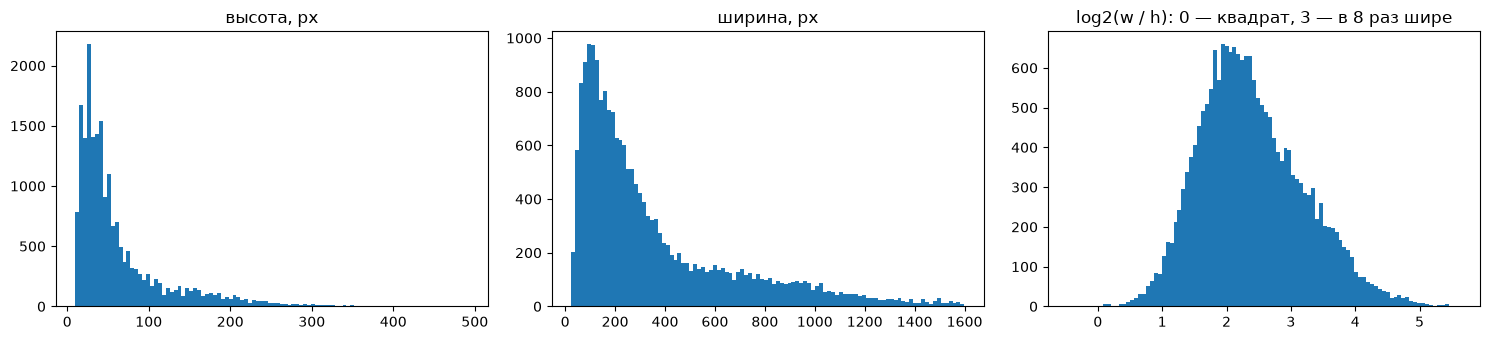

In [5]:
# 1.2 Размеры, цветовые режимы, битые файлы 
rows = []
for p in test_paths:
    try:
        with Image.open(p) as im:
            im.load()
            rows.append({"image_id": p.stem, "w": im.width, "h": im.height, "mode": im.mode, "ok": True})
    except Exception:
        rows.append({"image_id": p.stem, "w": np.nan, "h": np.nan, "mode": None, "ok": False})

eda = pd.DataFrame(rows)
eda["aspect"] = eda["w"] / eda["h"]  # > 1 — горизонтальная полоска, < 1 — вертикальная

print("битых файлов:", (~eda["ok"]).sum())
print("цветовые режимы:", dict(eda["mode"].value_counts()))
print(eda[["w", "h", "aspect"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
print("вертикальных (w/h < 1):", (eda["aspect"] < 1).sum(),
      "| почти квадратных (0.8–1.25):", eda["aspect"].between(0.8, 1.25).sum(),
      "| очень низких (h < 12 px):", (eda["h"] < 12).sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(eda["h"], bins=100)
axes[0].set_title("высота, px")
axes[1].hist(eda["w"], bins=100)
axes[1].set_title("ширина, px")
axes[2].hist(np.log2(eda["aspect"]), bins=100)
axes[2].set_title("log2(w / h): 0 — квадрат, 3 — в 8 раз шире")
plt.tight_layout()
plt.show()

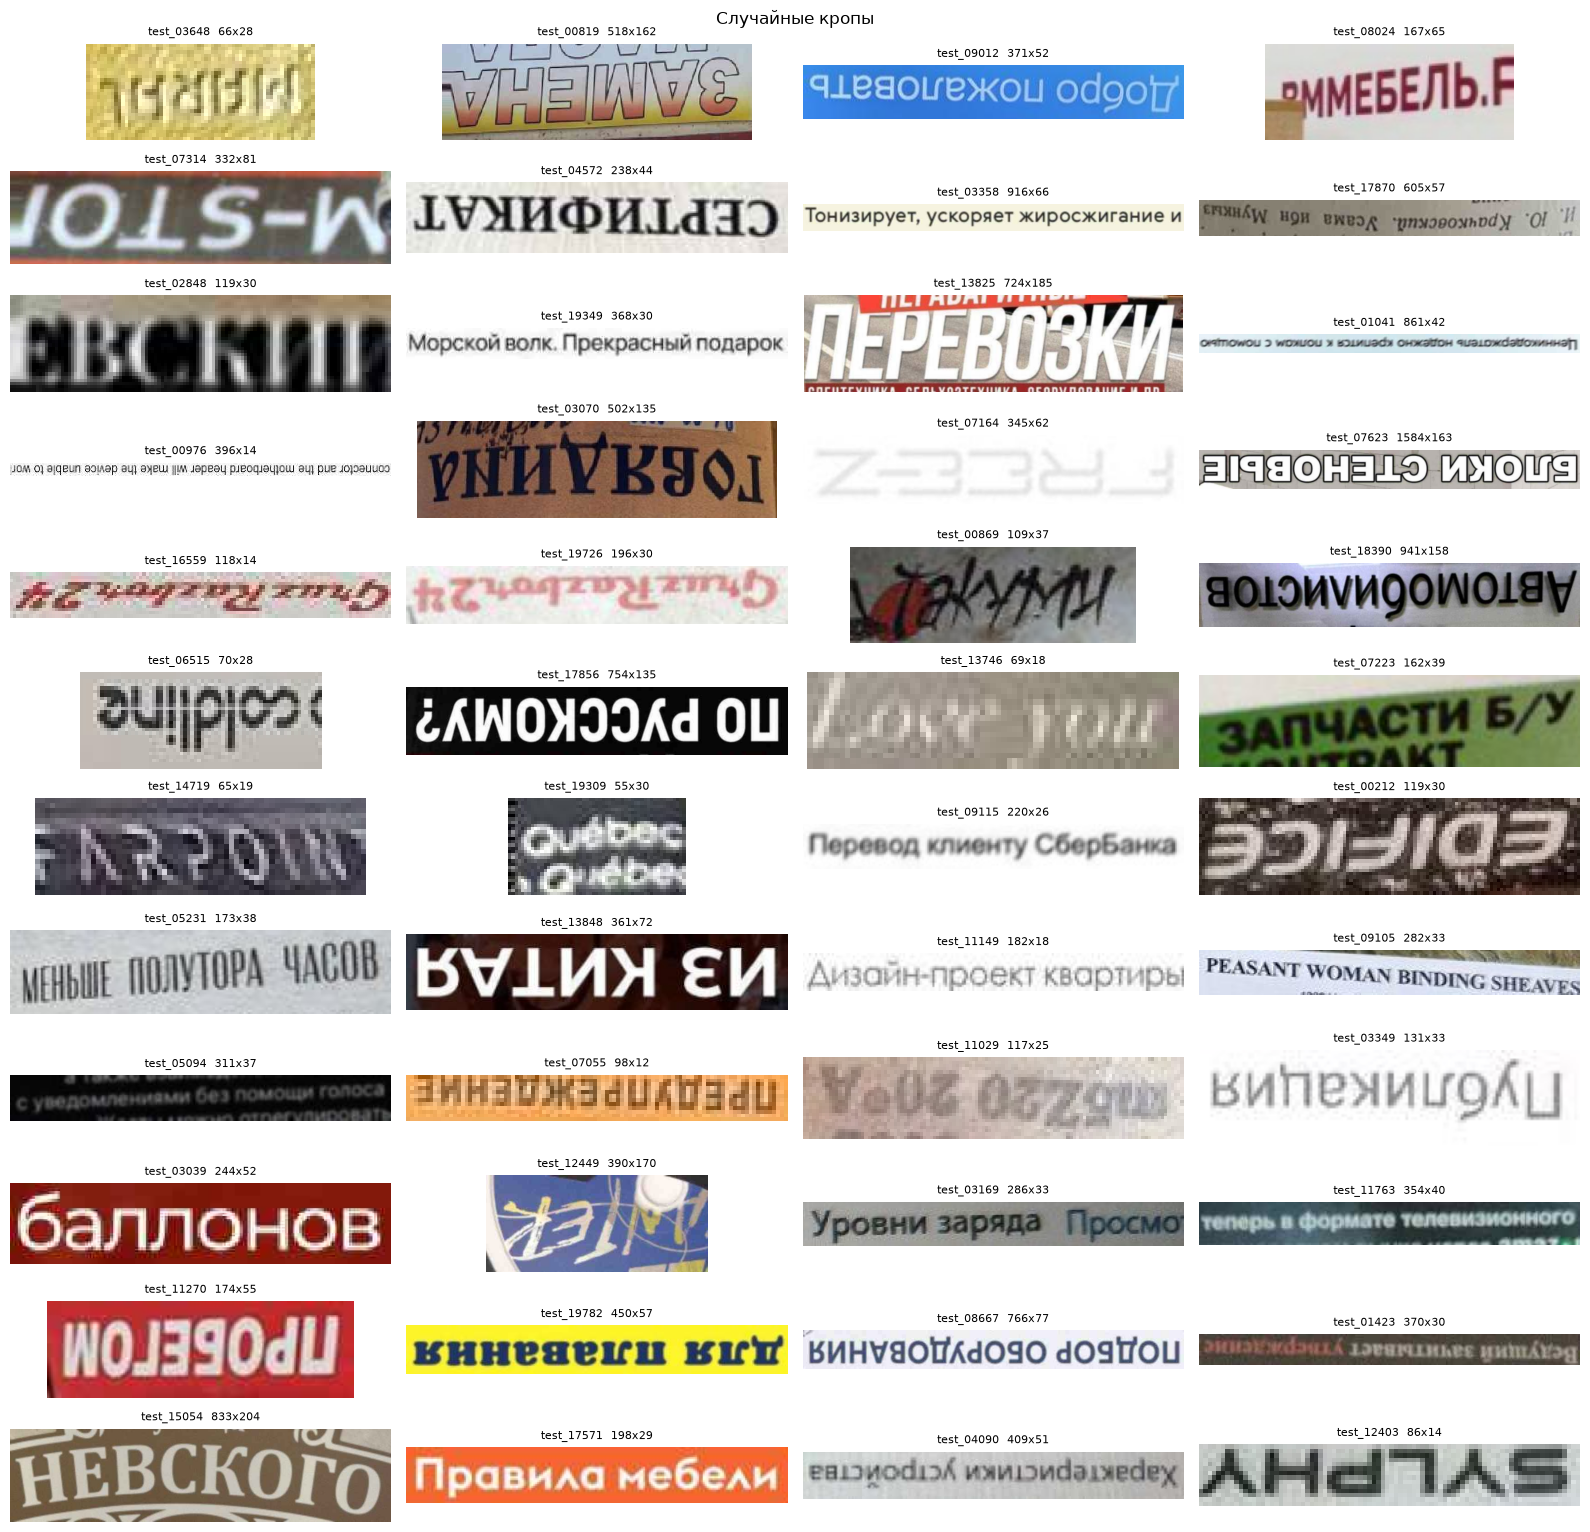

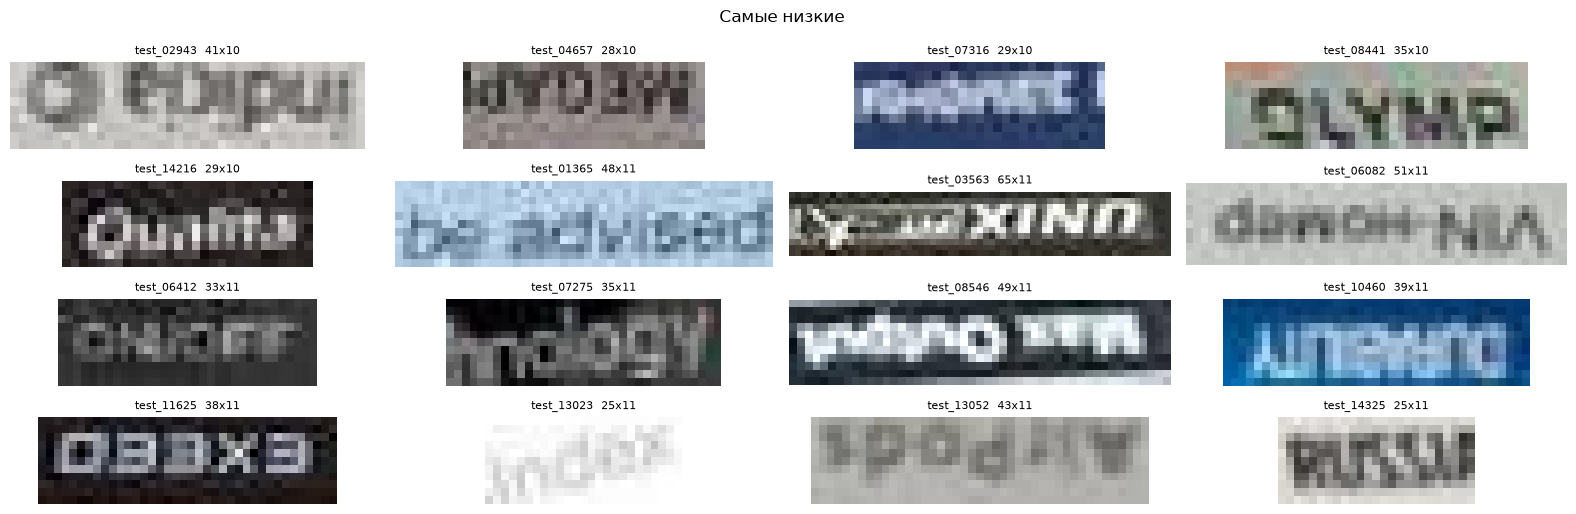

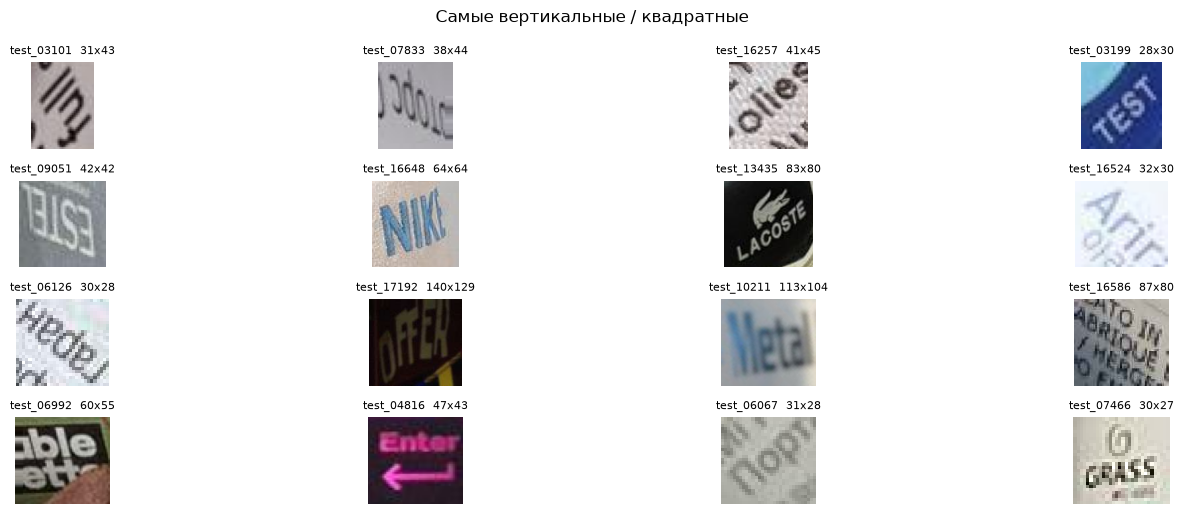

In [6]:
# 1.3 Визуальный осмотр: случайная выборка (фиксированный seed) + кандидаты в трудные случаи
def show_images(paths, title, ncols=4):
    # сетка картинок с подписью «имя  ширина x высота»
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.3 * nrows))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, p in zip(np.ravel(axes), paths):
        im = Image.open(p).convert("RGB")
        ax.imshow(im)
        ax.set_title(f"{p.stem}  {im.width}x{im.height}", fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


ok = eda[eda["ok"]]
rng = random.Random(SEED)
show_images([TEST_DIR / f"{i}.png" for i in rng.sample(list(ok["image_id"]), min(48, len(ok)))], "Случайные кропы")
show_images([TEST_DIR / f"{i}.png" for i in ok.nsmallest(16, "h")["image_id"]], "Самые низкие")
show_images([TEST_DIR / f"{i}.png" for i in ok.nsmallest(16, "aspect")["image_id"]], "Самые вертикальные / квадратные")

### 1.4 Выводы EDA

1. Формат. 20 000 png, все RGB, битых нет, `image_id` в сабмите — имя файла без расширения.
2. Размеры. Кропы маленькие: медианная высота 42 px, четверть ниже 27 px, минимум 10 px. → Вход высотой 48 px почти не искажает большинство кропов и остаётся дешёвым.
3. Пропорции. Почти всё — горизонтальные полоски: w/h медиана 4.9, 95% — до 14.5, максимум ~50. Вертикальных и квадратных 26 из 20 000. → Ресайз с сохранением пропорций и фиксированная ширина входа; длинные строки сжимаем по горизонтали.
4. Домен. Русский и английский вперемешку: вывески, баннеры, скриншоты интерфейсов, товары, сканы книг, стилизованные и рукописные шрифты. Много размытых, пиксельных, с артефактами сжатия, с обрезанными буквами и соседними строками в кадре. → Обучающие данные должны содержать кириллицу и латиницу, разные шрифты и фоны; аугментации: низкое разрешение, blur, JPEG, шум, цвет, сдвиги кропа.
5. Трудные случаи: текст под углом ~45°, кропы высотой 10 px, еле видный текст, симметричные строки и цифры (6 и 9). Здесь уверенного ответа нет → нужна калибровка, чтобы на них $p$ было ближе к 0.5.
6. Одна и та же надпись иногда встречается в нескольких кропах разного масштаба (детектор находит её несколько раз). На решение не влияет.

## 2. Обучающие данные

### 2.1 Идея: метки делаем сами

Нам не нужна разметка «повёрнут / не повёрнут». Достаточно кропов, где текст стоит правильно: поворот мы делаем сами и поэтому точно знаем ответ.

```
кроп, текст стоит правильно
        │
        ├── оставляем как есть ──────→ y = 0
        └── поворачиваем на 180° ────→ y = 1
```

Значит, настоящий вопрос не «где взять метки», а «где взять кропы, похожие на тест»: русский и английский текст на фото, вывесках, товарах и скриншотах.

### 2.2 Источник: RusTitW

RusTitW (Russian Text in the Wild, [arXiv:2303.16531](https://arxiv.org/abs/2303.16531), [Kaggle](https://www.kaggle.com/datasets/hardtype/rustitw-russian-language-visual-text-recognition)) — открытый датасет русского и английского текста на реальных фотографиях: вывески, реклама, товары, документы. У каждого текстового блока размечены бокс и текст. Есть и синтетическая часть, сгенерированная в стиле SynthText на реальных фонах.

- Реальные фото: train — 24 366, test — 3 795.
- Синтетика: ~850 тыс. картинок в train. Берём 2.5%, чтобы добавить разнообразия шрифтов.
- test/real используем как валидацию: это другие фотографии, чем в train, поэтому кропы одной фотографии не попадут и в обучение, и в валидацию.

### 2.3 Нарезка на кропы

Датасет весит ~175 ГБ, поэтому режем его прямо на Kaggle и скачиваем только кропы (`src/prepare_rustitw.py`, запуск — ячейка ниже с `PREPARE_DATA = True`).

- Разметка: прямоугольники в долях от размера картинки (0..1) и текст в поле `label`.
- Боксы бывают целыми абзацами, а тестовые кропы — отдельные строки. Многострочный бокс режем на n равных горизонтальных полос (n — число строк в `label`). Разрез приблизительный, но метку это не портит: её задаём мы сами поворотом.
- Отбрасываем боксы со стороной меньше 8 px (в тесте минимум 10) и вертикальные (w/h < 0.5): в тесте их почти нет.
- Вокруг бокса оставляем поле 10% высоты и записываем положение бокса внутри кропа (`bx0..by1`). При обучении из этого поля делаем случайные сдвиги кропа, как у неточного детектора.
- Храним кропы высотой не больше 64 px в JPEG q95.
- RGBA-картинки кладём на белый фон.

In [7]:
%%writefile src/prepare_rustitw.py
"""Нарезка RusTitW на строки-кропы.

Запускается на Kaggle: исходный датасет весит ~175 ГБ и лежит там, а скачиваем мы только
результат — папку кропов и crops.csv (~180 тыс. маленьких JPEG).
"""
import json
import os
from multiprocessing import Pool
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from src.utils import to_rgb

MAX_H = 64          # кропы храним высотой <= 64 px: вход модели 48, остаётся запас под аугментации
MIN_SIDE = 8        # боксы меньше 8 px отбрасываем (в тесте минимум 10 px)
MIN_ASPECT = 0.5    # вертикальный текст (w/h < 0.5) отбрасываем: в тесте его почти нет
MARGIN = 0.1        # поля вокруг бокса, доля высоты строки: из них при обучении делаем случайный сдвиг кропа
JPEG_Q = 95


def parse_boxes(s: str) -> list:
    """box_and_label — JSON-строка вида [[{left, top, width, height, label, shape}, ...]].
    Координаты — доли от размера картинки (0..1)."""
    boxes = []
    for item in json.loads(s):
        boxes.extend([item] if isinstance(item, dict) else item)
    return boxes


def split_lines(box: dict, W: int, H: int) -> list:
    """Переводим бокс в пиксели. Боксы в RusTitW бывают целыми абзацами (label с \\n),
    а тестовые кропы — отдельные строки. Поэтому многострочный бокс режем на n равных
    горизонтальных полос, n = число строк в label. Разрез приблизительный, но метка
    ориентации от этого не портится: её задаём мы сами поворотом."""
    x0, y0 = max(0.0, box["left"] * W), max(0.0, box["top"] * H)
    x1 = min(float(W), (box["left"] + box["width"]) * W)
    y1 = min(float(H), (box["top"] + box["height"]) * H)
    lines = [l.strip() for l in str(box.get("label", "")).split("\n") if l.strip()]
    n = max(1, len(lines))
    step = (y1 - y0) / n
    return [(x0, y0 + i * step, x1, y0 + (i + 1) * step, lines[i] if lines else "") for i in range(n)]


def process_image(task: tuple):
    """Одна исходная картинка -> список кропов-строк. Возвращает (записи, прочиталась_ли_картинка)."""
    split, source, img_path, boxes_json, out_dir = task
    if not isinstance(boxes_json, str):
        return [], True
    try:
        im = to_rgb(Image.open(img_path))
    except Exception:
        return [], False  # не прочиталась: считаем отдельно, чтобы не потерять данные молча
    W, H = im.size
    stem, recs = Path(img_path).stem, []
    for bi, box in enumerate(parse_boxes(boxes_json)):
        if box.get("shape", "rectangle") != "rectangle":
            continue
        for li, (x0, y0, x1, y1, text) in enumerate(split_lines(box, W, H)):
            w, h = x1 - x0, y1 - y0
            if w < MIN_SIDE or h < MIN_SIDE or w / h < MIN_ASPECT:
                continue
            m = MARGIN * h
            cx0, cy0 = max(0, int(x0 - m)), max(0, int(y0 - m))
            cx1, cy1 = min(W, int(np.ceil(x1 + m))), min(H, int(np.ceil(y1 + m)))
            crop = im.crop((cx0, cy0, cx1, cy1))
            s = min(1.0, MAX_H / crop.height)
            if s < 1:
                crop = crop.resize((max(1, round(crop.width * s)), MAX_H), Image.Resampling.LANCZOS)
            rel = Path(split) / source / f"{stem}_{bi}_{li}.jpg"
            crop.save(Path(out_dir) / rel, quality=JPEG_Q)
            recs.append(dict(path=str(rel), split=split, source=source, image=stem, text=text,
                             w=crop.width, h=crop.height,
                             # где внутри кропа лежит сам бокс (без полей) — для сдвигов при обучении
                             bx0=(x0 - cx0) * s, by0=(y0 - cy0) * s,
                             bx1=min(crop.width, (x1 - cx0) * s), by1=min(crop.height, (y1 - cy0) * s)))
    return recs, True


def prepare_crops(base: Path, out: Path, synth_frac: float = 0.025, seed: int = 42) -> pd.DataFrame:
    """Режем весь real (train и test) и долю synth_frac картинок из train/synth.
    synth из test не берём: валидация — только реальные фото из test/real."""
    base, out = Path(base), Path(out)
    sources = [("train", "real", 1.0), ("test", "real", 1.0), ("train", "synth", synth_frac)]
    tasks = []
    for split, source, frac in sources:
        root = base / split / source
        cols = pd.read_csv(root / "info.csv", nrows=0).columns
        use = ["image_name", "box_and_label"] + (["image_path"] if "image_path" in cols else [])
        df = pd.read_csv(root / "info.csv", usecols=use)
        if frac < 1:
            df = df.sample(frac=frac, random_state=seed)  # фиксированный seed -> та же подвыборка
        paths = df["image_path"] if "image_path" in df else "images/" + df["image_name"]
        (out / split / source).mkdir(parents=True, exist_ok=True)
        tasks += [(split, source, str(root / p), b, str(out)) for p, b in zip(paths, df["box_and_label"])]
        print(f"{split}/{source}: картинок {len(df)}")

    recs, n_fail = [], 0
    with Pool(os.cpu_count()) as pool:
        for r, ok in tqdm(pool.imap_unordered(process_image, tasks, chunksize=16), total=len(tasks)):
            recs += r
            n_fail += not ok
    # imap_unordered отдаёт результаты в случайном порядке — сортируем, чтобы csv был детерминированным
    crops = pd.DataFrame(recs).sort_values("path").reset_index(drop=True)
    crops.to_csv(out / "crops.csv", index=False)
    print("не прочитались картинки:", n_fail)
    return crops


def check_exif(base: Path) -> pd.Series:
    """Считаем EXIF-ориентации real-фото. Если бы пиксели хранились «лёжа» или вверх ногами
    (тег != 1), боксы разметки не совпали бы с сырыми пикселями, а при теге 3 перевёрнутый
    текст получил бы метку «стоит правильно». Читается только заголовок файла."""
    orients = []
    for split in ["train", "test"]:
        root = Path(base) / split / "real"
        df = pd.read_csv(root / "info.csv", usecols=lambda c: c in {"image_name", "image_path"})
        paths = df["image_path"] if "image_path" in df else "images/" + df["image_name"]
        for p in tqdm(paths, desc=split):
            with Image.open(root / p) as im:
                orients.append(im.getexif().get(0x0112, 1))
    return pd.Series(orients, name="exif_orientation").value_counts()

Overwriting src/prepare_rustitw.py


In [8]:
# 2.4 Запуск нарезки — только на Kaggle с подключённым датасетом RusTitW.
# Результат: /kaggle/working/rustitw_crops.zip -> распаковать локально в data/rustitw_crops
import shutil

RUSTITW_BASE = Path("/kaggle/input/datasets/hardtype/rustitw-russian-language-visual-text-recognition")
KAGGLE_OUT = Path("/kaggle/working/rustitw_crops")

if PREPARE_DATA:
    from src.prepare_rustitw import prepare_crops, check_exif

    prepared = prepare_crops(RUSTITW_BASE, KAGGLE_OUT, synth_frac=0.025, seed=SEED)
    print(prepared.groupby(["split", "source"]).size())
    print(check_exif(RUSTITW_BASE))  # ожидаем только 1: пиксели хранятся так, как их видели разметчики
    shutil.make_archive(str(KAGGLE_OUT), "zip", KAGGLE_OUT)

### 2.5 Результат нарезки

| | картинок | кропов |
|---|---|---|
| train/real | 24 366 | 96 171 |
| train/synth (2.5%) | 21 302 | 64 041 |
| test/real → валидация | 3 795 | 17 599 |
| итого | 49 463 | 177 811 |

- Ошибок чтения: 0.
- EXIF-ориентация у всех 28 161 реальных фото равна 1, то есть пиксели лежат так, как их видели разметчики. Это важно: при EXIF-повороте на 180° перевёрнутый текст получил бы метку «стоит правильно».
- Медианный кроп 162 × 64 px: с полями w/h ≈ 2.5, в тесте 4.9. В RusTitW больше однословных боксов, а детектор Авито чаще выдаёт строки. Компенсируем аугментацией горизонтального масштаба (раздел 3).

C:\Users\rodio\AppData\Local\Temp\ipykernel_11152\2051467269.py:21: DtypeWarning: Columns (3: image) have mixed types. Specify dtype option on import or set low_memory=False.
  crops = pd.read_csv(CROPS_DIR / "crops.csv")


split  source
test   real      17599
train  real      96171
       synth     64041
dtype: int64


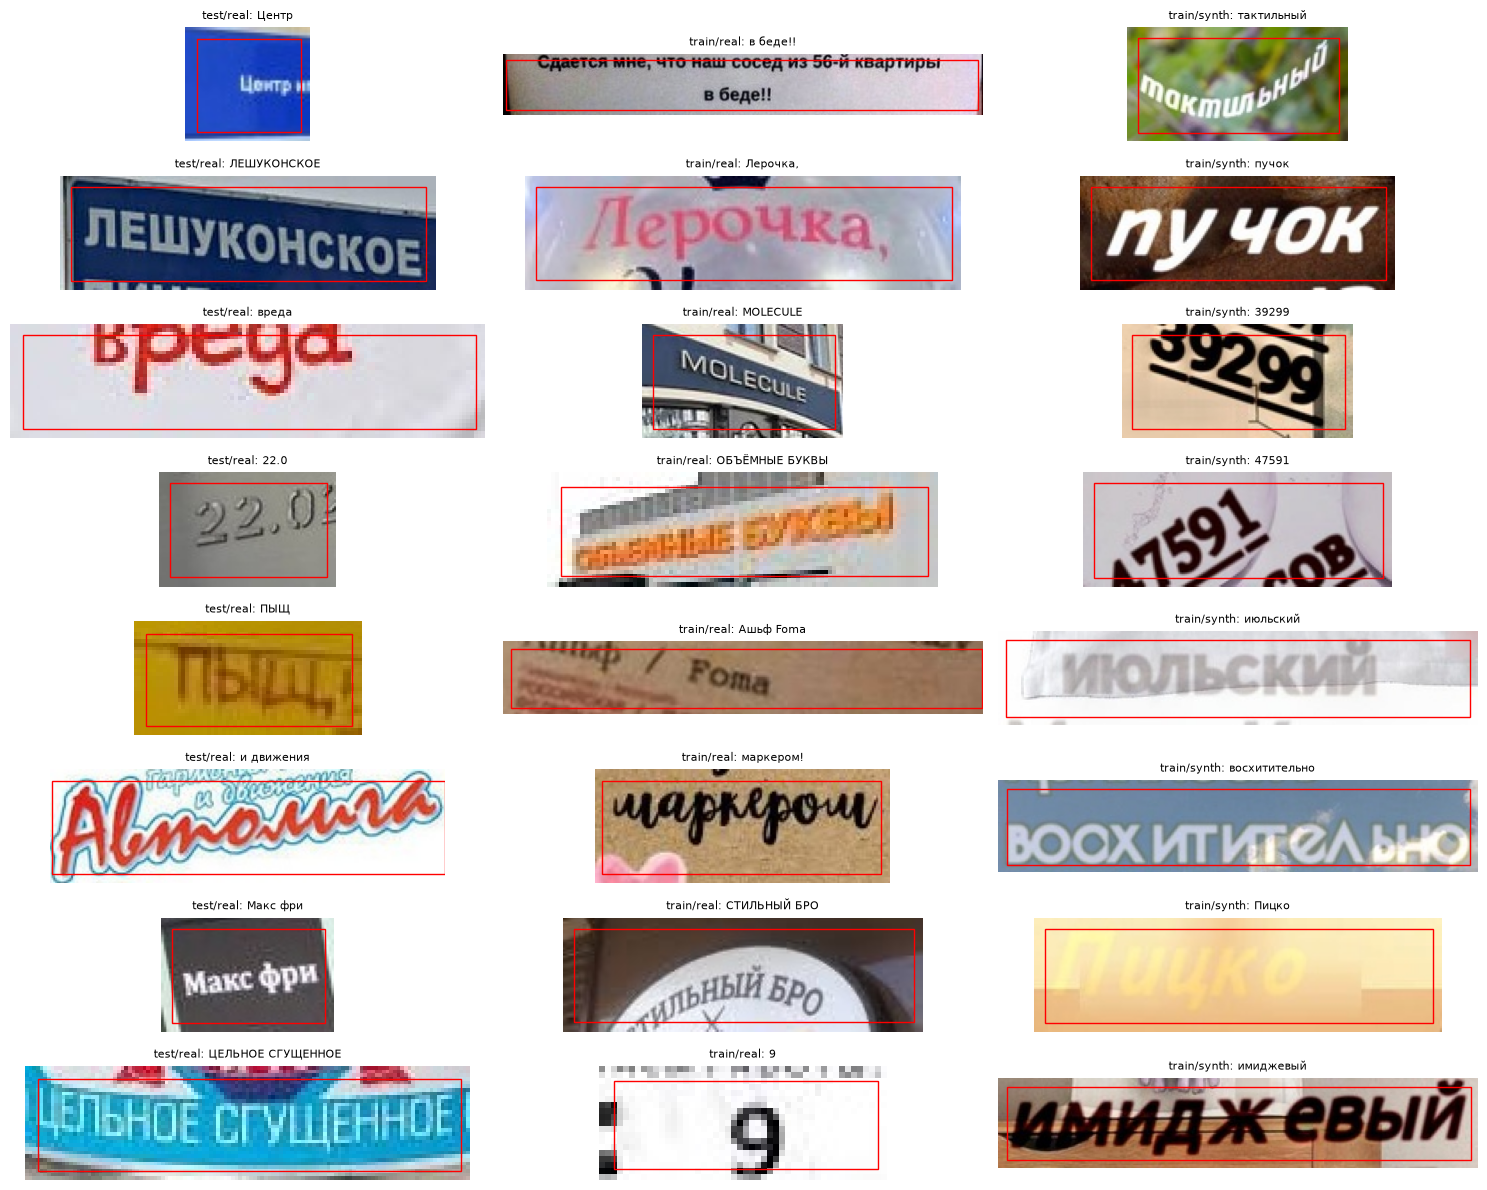

In [9]:
# 2.6 Проверка глазами: по 8 случайных кропов из каждого источника; красная рамка — исходный бокс
import matplotlib.patches as patches


def show_crops_with_boxes(crops, n=8):
    groups = list(crops.groupby(["split", "source"]))
    fig, axes = plt.subplots(n, len(groups), figsize=(5 * len(groups), 1.5 * n))
    for ax in axes.ravel():
        ax.axis("off")
    for col, ((split, source), g) in enumerate(groups):
        for ax, r in zip(axes[:, col], g.sample(min(n, len(g)), random_state=SEED).itertuples()):
            ax.imshow(Image.open(CROPS_DIR / r.path))
            ax.add_patch(patches.Rectangle((r.bx0, r.by0), r.bx1 - r.bx0, r.by1 - r.by0,
                                           fill=False, ec="red", lw=1))
            ax.set_title(f"{split}/{source}: {str(r.text)[:30]}", fontsize=8)
    plt.tight_layout()
    plt.show()


if HAS_CROPS:
    crops = pd.read_csv(CROPS_DIR / "crops.csv")
    print(crops.groupby(["split", "source"]).size())
    show_crops_with_boxes(crops)
else:
    print("Кропов RusTitW нет (data/rustitw_crops) — пропускаем, они нужны только для обучения")

Что видно на сетке:
- текст на кропах стоит правильно, рамки в основном попадают на текст;
- разрез абзацев иногда промахивается: в полосу попадает соседняя строка или почти пустой фон (например, текст по кругу). Метку это не портит, а в тесте такие кропы тоже встречаются, поэтому оставляем.

## 3. Препроцессинг, аугментации, датасеты

### 3.1 Препроцессинг (одинаковый для train, валидации и теста)

1. Кроп → RGB.
2. Высота → 48 px с сохранением пропорций.
3. Если шире 192 px — сжимаем по горизонтали до 192: вертикальная форма букв, по которой и видно верх и низ, при этом сохраняется. Если уже — паддинг по центру цветом среднего ImageNet (после нормализации это ≈ 0).
4. Нормализация средним и стандартным отклонением ImageNet (backbone предобучен на ImageNet).

Почему 48 × 192: это вход классификатора ориентации строк в PaddleOCR. Медианная высота теста 42 px, поэтому 48 почти не искажает кропы, а 32 потеряло бы детали у крупных надписей. Ширина 192 покрывает пропорцию 4 : 1, длинные строки сжимаются.

### 3.2 Метка и три правила

Метка: кроп как есть — y = 0, повёрнутый на 180° — y = 1 (при обучении модель видит обе версии, см. 3.4). Чтобы модель выучила ориентацию текста, а не случайный артефакт:

1. Поворот делаем до ресайза и паддинга. Иначе у перевёрнутых картинок паддинг и ресайз вели бы себя иначе и подсказывали метку.
2. Никаких отражений (flip): зеркального текста в тесте нет.
3. Всё, что зависит от геометрии кропа (сдвиги, наклон), делаем до поворота, а деградации качества (низкое разрешение, blur, JPEG, шум) — после. Так их артефакты не привязаны к одной ориентации.

### 3.3 Аугментации (только train)

| Аугментация | Параметры | Зачем (связь с EDA) |
|---|---|---|
| сдвиг кропа | границы случайно между «впритык к боксу» и полным полем; иногда подрезаем до 10% текста | детектор ошибается, в тесте есть обрезанные буквы |
| горизонтальный масштаб | ×0.5–1.5, p = 0.5 | наши кропы короче тестовых (w/h 2.5 против 4.9), в тесте буквы длинных строк сжаты |
| наклон | ±7°, p = 0.3 | текст в боксах бывает под углом; модель не должна путать «наклонён» и «перевёрнут» |
| цвет | яркость, контраст, насыщенность (p = 0.8), ч/б (0.1), инверсия (0.1) | разные фоны, светлый текст на тёмном |
| низкое разрешение | сжать до высоты 12–32 px и растянуть, p = 0.3 | в тесте 5% кропов ниже 16 px, четверть ниже 27 px |
| blur | Gaussian, радиус 0.3–1.5, p = 0.2 | размытые кропы |
| JPEG | качество 20–80, p = 0.3 | артефакты сжатия |
| шум | гауссов, σ = 3–12, p = 0.1 | шумные фото |

### 3.4 Датасеты

- `CropDataset(train=True, paired=True)` — обучение на train/real + train/synth парами: один и тот же кроп в двух ориентациях (y = 0 и y = 1) с одинаковыми аугментациями, внутри пары отличается только поворот. Так модели не на что опереться, кроме ориентации текста. Приём из RotNet (Gidaris et al., 2018): подача всех повёрнутых копий изображения в один батч вместо случайного поворота дала заметный прирост. На пары перешли после первого прогона (раздел 9). Без `paired` датасет отдаёт одиночный кроп со случайным поворотом — так он показан на сетке ниже.
- `CropDataset(train=False)` — валидация на test/real: кроп строго по боксу без полей (как у детектора), без аугментаций, повороты фиксированы seed'ом, поэтому набор одинаковый при каждом запуске.
- `TestDataset` — тестовые кропы Авито: только препроцессинг.
- `make_loader` — DataLoader с фиксированным генератором: порядок батчей и seed'ы воркеров, а значит и аугментации, воспроизводятся. Для парного датасета склеивает пары в обычный батч (batch_size — число пар).

In [10]:
%%writefile src/data.py
"""Препроцессинг, аугментации и датасеты для классификации поворота кропа (0° / 180°).

Главные правила (от них зависит, выучит ли модель ориентацию, а не артефакт):
1. Поворот на 180° делается ДО resize_pad. Тогда паддинг одинаковый для обоих классов
   и не подсказывает метку.
2. Никаких отражений (flip): зеркального текста в тесте нет.
3. Всё, что зависит от ориентации (сдвиги кропа, наклон), делаем до поворота;
   деградации (низкое разрешение, blur, JPEG, шум) — после поворота, чтобы их
   артефакты не были «привязаны» к одной ориентации.
"""
from io import BytesIO
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
from torch.utils.data import DataLoader, Dataset

from src.utils import to_rgb

IMG_H, IMG_W = 48, 192                   # вход модели: как у классификатора ориентации PaddleOCR
MEAN = (0.485, 0.456, 0.406)             # нормализация ImageNet (backbone предобучен на ImageNet)
STD = (0.229, 0.224, 0.225)
PAD_COLOR = tuple(round(m * 255) for m in MEAN)  # паддинг цветом среднего -> после нормализации ≈ 0
BILINEAR = Image.Resampling.BILINEAR


# ---------------------------------------------------------------- препроцессинг (train = val = test)

def resize_pad(img: Image.Image, h: int = IMG_H, w: int = IMG_W) -> Image.Image:
    """Высота -> h с сохранением пропорций. Если кроп шире w — сжимаем по ширине до w
    (вертикальная форма букв, по которой видно верх/низ, сохраняется). Если уже — паддинг
    по центру цветом среднего."""
    new_w = max(1, min(w, round(img.width * h / img.height)))
    img = img.resize((new_w, h), BILINEAR)
    if new_w == w:
        return img
    canvas = Image.new("RGB", (w, h), PAD_COLOR)
    canvas.paste(img, ((w - new_w) // 2, 0))
    return canvas


_MEAN = np.array(MEAN, dtype=np.float32)
_STD = np.array(STD, dtype=np.float32)


def to_tensor(img: Image.Image) -> torch.Tensor:
    """PIL RGB (H, W, 3) uint8 -> нормализованный тензор (3, H, W) float32."""
    x = (np.asarray(img, dtype=np.float32) / 255.0 - _MEAN) / _STD
    return torch.from_numpy(x.transpose(2, 0, 1).copy())


def denormalize(t: torch.Tensor) -> np.ndarray:
    """Обратно в картинку (H, W, 3) в [0, 1] — только для визуализации."""
    return np.clip(t.numpy().transpose(1, 2, 0) * _STD + _MEAN, 0, 1)


def preprocess(img: Image.Image) -> torch.Tensor:
    """Единый путь для валидации и теста: RGB -> resize_pad -> тензор."""
    return to_tensor(resize_pad(to_rgb(img)))


# ---------------------------------------------------------------- аугментации

def _border_color(img: Image.Image) -> tuple:
    """Медианный цвет рамки кропа — им заливаем углы после наклона, чтобы не было чёрных треугольников."""
    a = np.asarray(img)
    border = np.concatenate([a[0], a[-1], a[:, 0], a[:, -1]])
    return tuple(int(v) for v in np.median(border, axis=0))


def jitter_crop(img: Image.Image, box, rng: np.random.Generator) -> Image.Image:
    """Случайный кроп вокруг бокса: имитирует неточность детектора.
    Каждая граница — случайно между «впритык к боксу» и «всё сохранённое поле» (10% высоты).
    Иногда подрезаем текст сбоку/сверху: в тесте тоже бывают обрезанные буквы."""
    W, H = img.size
    bx0, by0, bx1, by1 = box
    bw, bh = bx1 - bx0, by1 - by0
    x0, x1 = rng.uniform(0, bx0), rng.uniform(bx1, W)
    y0, y1 = rng.uniform(0, by0), rng.uniform(by1, H)
    if rng.random() < 0.3:
        cut = rng.uniform(0, 0.1) * bw
        if rng.random() < 0.5:
            x0 += cut
        else:
            x1 -= cut
    if rng.random() < 0.2:
        cut = rng.uniform(0, 0.1) * bh
        if rng.random() < 0.5:
            y0 += cut
        else:
            y1 -= cut
    x0, y0 = int(x0), int(y0)
    x1 = min(W, max(x0 + 4, int(np.ceil(x1))))
    y1 = min(H, max(y0 + 4, int(np.ceil(y1))))
    return img.crop((x0, y0, x1, y1))


def augment_upright(img: Image.Image, box, rng: np.random.Generator) -> Image.Image:
    """Аугментации, которые делаем ДО поворота на 180° (текст ещё стоит правильно)."""
    img = jitter_crop(img, box, rng)
    # горизонтальное растяжение/сжатие: у наших кропов w/h ~2.5, у теста ~5 и длинные строки
    # сжимаются в resize_pad -> учим модель узким буквам
    if rng.random() < 0.5:
        f = float(np.exp(rng.uniform(np.log(0.5), np.log(1.5))))
        img = img.resize((max(4, round(img.width * f)), img.height), BILINEAR)
    # небольшой наклон: текст в тестовых боксах бывает под углом, модель не должна путать
    # «наклонён» и «перевёрнут»
    if rng.random() < 0.3:
        img = img.rotate(rng.uniform(-7, 7), resample=BILINEAR, expand=True,
                         fillcolor=_border_color(img))
    # цвет: яркость, контраст, насыщенность; иногда ч/б и инверсия (светлый текст на тёмном)
    if rng.random() < 0.8:
        img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.6, 1.4))
        img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.6, 1.4))
        img = ImageEnhance.Color(img).enhance(rng.uniform(0.5, 1.5))
    if rng.random() < 0.1:
        img = ImageOps.grayscale(img).convert("RGB")
    if rng.random() < 0.1:
        img = ImageOps.invert(img)
    return img


def degrade(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    """Деградации качества ПОСЛЕ поворота: пиксельные, размытые и пережатые кропы из EDA."""
    if rng.random() < 0.3:  # низкое разрешение: сжать до высоты 12–32 px и растянуть обратно
        # (в тесте 5% кропов ниже 16 px и четверть ниже 27 px)
        th = int(rng.integers(12, 33))
        if th < img.height:
            small = img.resize((max(2, round(img.width * th / img.height)), th), BILINEAR)
            img = small.resize(img.size, BILINEAR)
    if rng.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.5)))
    if rng.random() < 0.3:  # JPEG-артефакты
        buf = BytesIO()
        img.save(buf, "JPEG", quality=int(rng.integers(20, 81)))
        buf.seek(0)
        img = Image.open(buf).convert("RGB")
    if rng.random() < 0.1:  # гауссов шум
        a = np.asarray(img, dtype=np.float32)
        a += rng.normal(0, rng.uniform(3, 12), a.shape)
        img = Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))
    return img


# ---------------------------------------------------------------- датасеты

class CropDataset(Dataset):
    """Кропы RusTitW. Метку y создаём сами: y=1 — повернули на 180°, y=0 — оставили.

    train=True:  случайный поворот (монетка заново на каждой эпохе) + аугментации.
    train=True, paired=True: пара из одного и того же кропа в двух ориентациях (y=0 и y=1)
                 с одинаковыми аугментациями — отличается только поворот (как в RotNet).
    train=False: валидация. Кроп строго по боксу (без полей, как у детектора),
                 без аугментаций, поворот фиксирован seed'ом -> набор одинаковый при каждом запуске.
    """

    def __init__(self, df, root, train: bool, seed: int = 42, paired: bool = False):
        self.root = Path(root)
        self.paths = df["path"].tolist()
        self.boxes = df[["bx0", "by0", "bx1", "by1"]].to_numpy(np.float32)
        self.train = train
        self.paired = train and paired
        self.labels = None if train else np.random.default_rng(seed).integers(0, 2, len(df))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = to_rgb(Image.open(self.root / self.paths[i]))
        if self.train:
            # генератор на каждый вызов из torch RNG: в воркерах DataLoader torch сам даёт
            # каждому воркеру свой seed от seed'а загрузчика -> аугментации воспроизводимы
            rng = np.random.default_rng(int(torch.randint(0, 2**31 - 1, (1,))))
            img = augment_upright(img, self.boxes[i], rng)
            if self.paired:
                # один seed деградаций для обеих копий: у пары отличается только ориентация
                deg_seed = int(rng.integers(0, 2**31 - 1))
                up = degrade(img, np.random.default_rng(deg_seed))
                rot = degrade(img.transpose(Image.Transpose.ROTATE_180), np.random.default_rng(deg_seed))
                x = torch.stack([to_tensor(resize_pad(up)), to_tensor(resize_pad(rot))])
                return x, torch.tensor([0.0, 1.0])
            y = int(rng.random() < 0.5)
            if y:
                img = img.transpose(Image.Transpose.ROTATE_180)
            img = degrade(img, rng)
        else:
            x0, y0, x1, y1 = self.boxes[i]
            img = img.crop((int(x0), int(y0), max(int(x0) + 1, int(np.ceil(x1))),
                            max(int(y0) + 1, int(np.ceil(y1)))))
            y = int(self.labels[i])
            if y:
                img = img.transpose(Image.Transpose.ROTATE_180)
        return to_tensor(resize_pad(img)), torch.tensor(y, dtype=torch.float32)


class TestDataset(Dataset):
    """Тестовые кропы Авито: только препроцессинг, без поворотов и аугментаций."""

    def __init__(self, paths):
        self.paths = [Path(p) for p in paths]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        return preprocess(Image.open(self.paths[i])), i


def collate_pairs(batch):
    """Пары (2, 3, H, W) склеиваем в обычный батч: B пар -> 2B картинок, метки [0, 1, 0, 1, ...]."""
    xs, ys = zip(*batch)
    return torch.cat(xs), torch.cat(ys)


def make_loader(ds, shuffle: bool, batch_size: int = 256, num_workers: int = 4, seed: int = 42):
    """DataLoader с фиксированным генератором: он задаёт порядок батчей и seed'ы воркеров,
    поэтому аугментации воспроизводятся от запуска к запуску.
    Для парного датасета batch_size — число пар, в батче будет вдвое больше картинок."""
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers,
                      generator=torch.Generator().manual_seed(seed),
                      collate_fn=collate_pairs if getattr(ds, "paired", False) else None,
                      pin_memory=torch.cuda.is_available(), persistent_workers=num_workers > 0)

Overwriting src/data.py


вход модели: 48 x 192 | тестовых кропов: 20000
train: 160212 кропов (в эпохе вдвое больше картинок) | val: 17599 | доля y=1 в валидации: 0.497


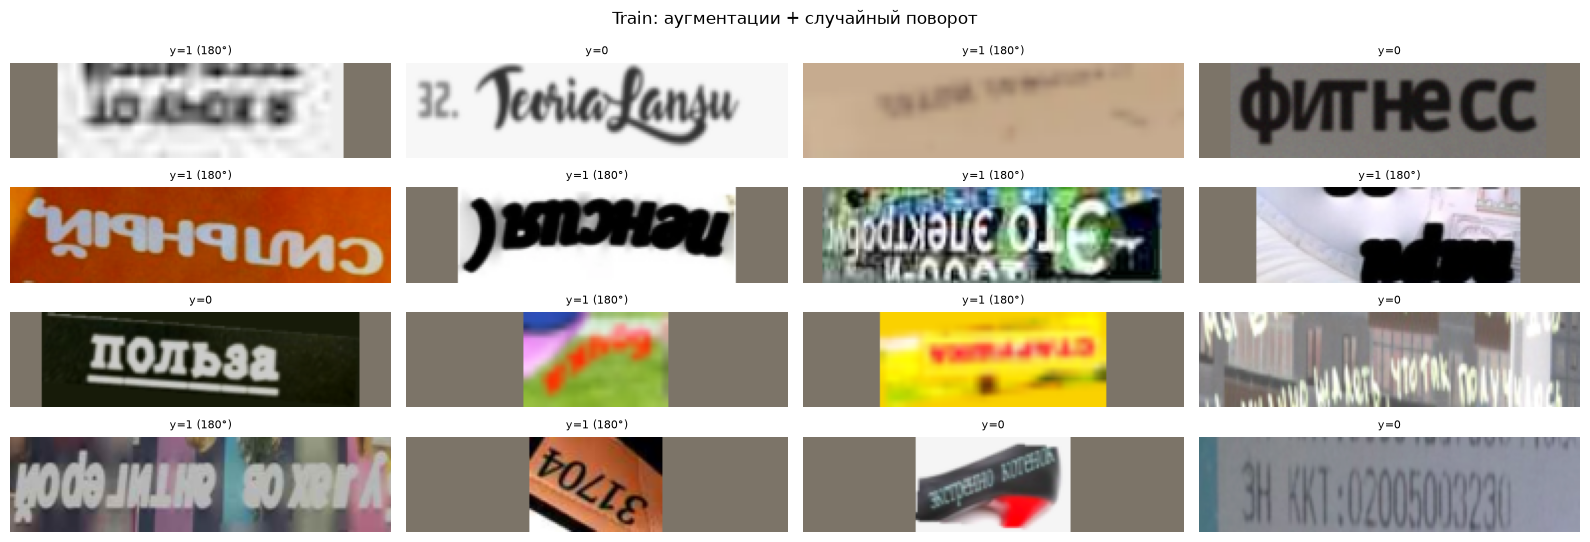

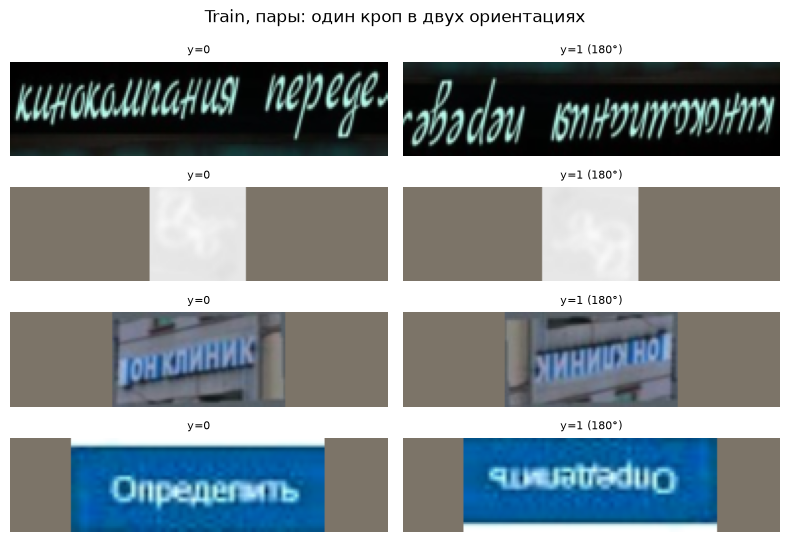

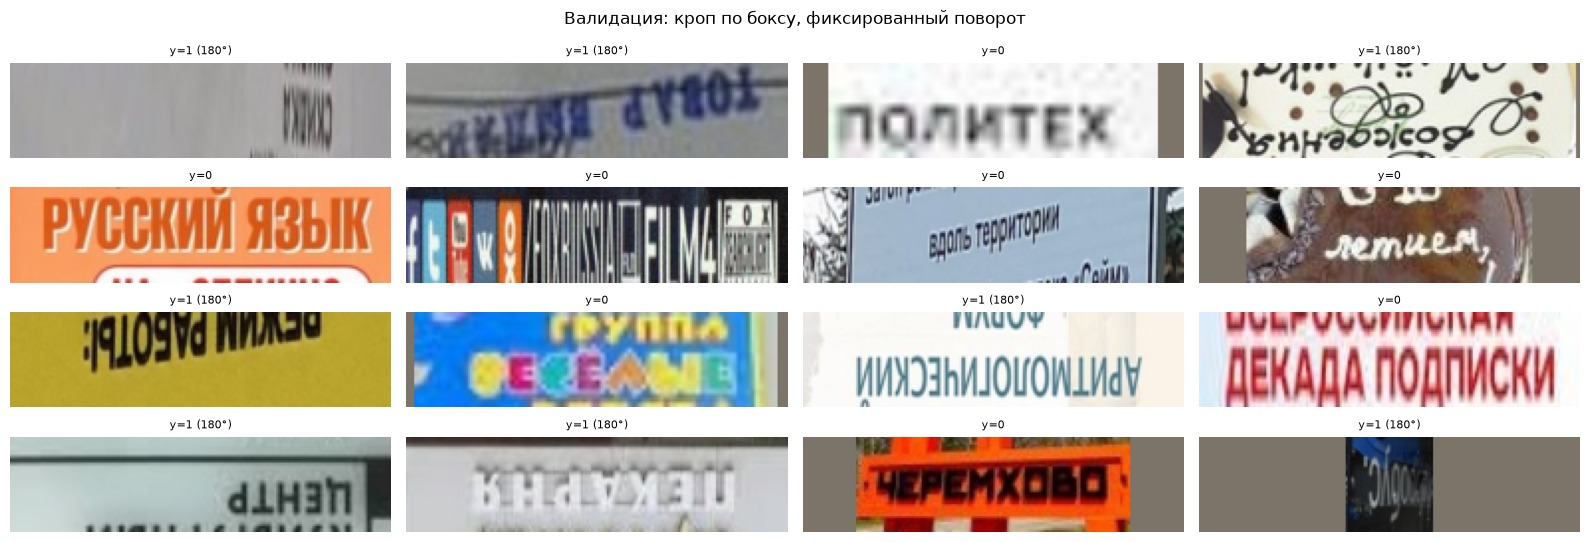

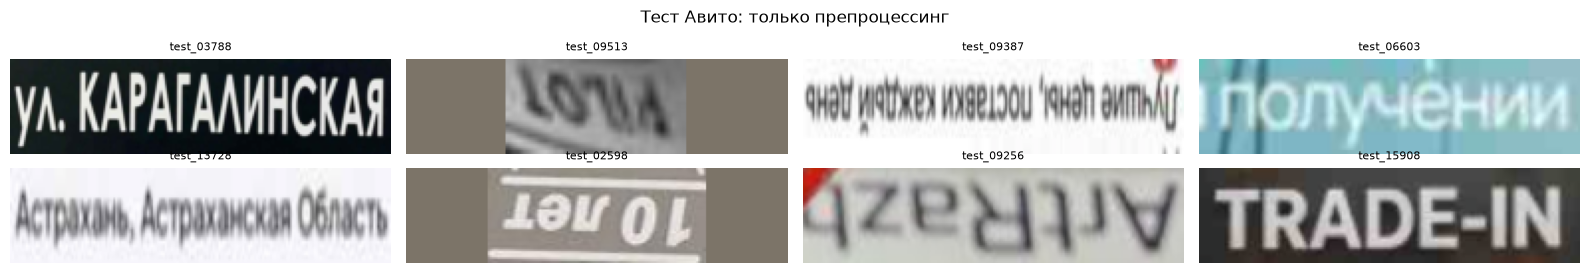

In [11]:
# 3.5 Датасеты и проверка глазами: смотрим ровно то, что попадёт в модель
from src.data import CropDataset, TestDataset, denormalize, make_loader, IMG_H, IMG_W


def show_inputs(ds, idx, title, names=None, ncols=4):
    # сетка входов модели (после препроцессинга и аугментаций) с меткой или именем файла
    nrows = int(np.ceil(len(idx) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.4 * nrows))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, i in zip(np.ravel(axes), idx):
        x, y = ds[i]
        ax.imshow(denormalize(x))
        ax.set_title(names[i] if names else ("y=1 (180°)" if y == 1 else "y=0"), fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_pairs(ds, idx):
    # пары для обучения: один и тот же кроп с одинаковыми аугментациями в двух ориентациях
    fig, axes = plt.subplots(len(idx), 2, figsize=(8, 1.4 * len(idx)))
    for row, i in zip(axes, idx):
        x, y = ds[i]
        for ax, xi, yi in zip(row, x, y):
            ax.imshow(denormalize(xi))
            ax.axis("off")
            ax.set_title("y=1 (180°)" if yi == 1 else "y=0", fontsize=8)
    fig.suptitle("Train, пары: один кроп в двух ориентациях")
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(SEED)
test_ds = TestDataset(test_paths)
print("вход модели:", IMG_H, "x", IMG_W, "| тестовых кропов:", len(test_ds))

if HAS_CROPS:
    train_df = crops[crops["split"] == "train"].reset_index(drop=True)  # train/real + train/synth
    val_df = crops[crops["split"] == "test"].reset_index(drop=True)     # test/real
    train_ds = CropDataset(train_df, CROPS_DIR, train=True, paired=True)  # обучение: пары 0° и 180°
    val_ds = CropDataset(val_df, CROPS_DIR, train=False, seed=SEED)
    print("train:", len(train_ds), "кропов (в эпохе вдвое больше картинок) | val:", len(val_ds),
          "| доля y=1 в валидации:", val_ds.labels.mean().round(3))

    show_inputs(CropDataset(train_df, CROPS_DIR, train=True), rng.choice(len(train_df), 16, replace=False),
                "Train: аугментации + случайный поворот")
    show_pairs(train_ds, rng.choice(len(train_ds), 4, replace=False))
    show_inputs(val_ds, rng.choice(len(val_ds), 16, replace=False), "Валидация: кроп по боксу, фиксированный поворот")

show_inputs(test_ds, rng.choice(len(test_ds), min(8, len(test_ds)), replace=False),
            "Тест Авито: только препроцессинг", names=[p.stem for p in test_paths])

In [12]:
# 3.6 DataLoader: форма батча, баланс классов и воспроизводимость аугментаций
if HAS_CROPS:
    xb1, yb1 = next(iter(make_loader(train_ds, shuffle=True, batch_size=64, num_workers=NUM_WORKERS, seed=SEED)))
    xb2, yb2 = next(iter(make_loader(train_ds, shuffle=True, batch_size=64, num_workers=NUM_WORKERS, seed=SEED)))
    print("батч:", tuple(xb1.shape), "| доля y=1:", yb1.mean().item())
    print("два запуска с одним seed дают один и тот же батч:", torch.equal(xb1, xb2) and torch.equal(yb1, yb2))

батч: (128, 3, 48, 192) | доля y=1: 0.5
два запуска с одним seed дают один и тот же батч: True


## 4. Модель

### 4.1 Выбор архитектуры

Требования: модель применяется к каждому боксу, поэтому она должна быть маленькой и быстрой на CPU, а качество — упираться в данные, а не в размер сети. Задача локальная: верх и низ строки видны по форме букв (выносные элементы, засечки, где у букв «тяжёлая» часть), поэтому хватает небольшой свёрточной сети.

Берём MobileNetV3-large из torchvision:
- есть веса, предобученные на ImageNet: низкоуровневые признаки (края, штрихи) переиспользуются, модель быстрее сходится на наших данных;
- входит в torchvision, дополнительных зависимостей нет.

### 4.2 Адаптация под задачу

- Родную голову на 1000 классов ImageNet заменяем на Dropout(0.2) + Linear(960 → 1). Выход модели — одно число, логит $z$.
- Вероятность поворота получаем сигмоидой от логита. В разделе 6 перед сигмоидой логит делится на температуру $T$ — так калибруются вероятности.

- Вход 3 × 48 × 192. После всех свёрток остаётся арта 2 × 6 с 960 каналами, GAP усредняет её в вектор из 960 чисел
- Для обучения берём веса ImageNet (`pretrained=True`), для инференса — пустую архитектуру и загружаем в неё свои веса: ничего не скачивается.

### 4.3 Размер и вычисления

Ниже считаем число параметров, размер весов и FLOPs на один кроп. Задержку на CPU замеряем в разделе 7.

In [13]:
%%writefile src/model.py
"""Модель: MobileNetV3-Large (torchvision) с одним выходом — логитом поворота на 180°."""
import torch
from torch import nn
from torch.utils.flop_counter import FlopCounterMode
from torchvision.models import MobileNet_V3_Large_Weights, mobilenet_v3_large


def build_model(pretrained: bool = True) -> nn.Module:
    """MobileNetV3-Large. pretrained=True — веса ImageNet (для обучения);
    False — пустая архитектура (для инференса: веса потом грузим свои, ничего не скачиваем).
    Родную голову на 1000 классов ImageNet заменяем на Dropout + Linear(960 -> 1)."""
    weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2 if pretrained else None
    model = mobilenet_v3_large(weights=weights)
    in_features = model.classifier[0].in_features  # 960 каналов после global average pooling
    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_features, 1))
    return model


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def count_flops(model: nn.Module, input_size=(1, 3, 48, 192)) -> int:
    """FLOPs одного прохода (умножение и сложение считаются отдельно, MACs = FLOPs / 2).
    Считаются свёртки и линейные слои — это почти все вычисления сети."""
    model.eval()
    counter = FlopCounterMode(display=False)
    with counter:
        model(torch.zeros(input_size))
    return counter.get_total_flops()

Overwriting src/model.py


In [14]:
# 4.4 Проверка архитектуры: форма выходов, число параметров, FLOPs
from src.model import build_model, count_params, count_flops

model_check = build_model(pretrained=False).eval()
x = torch.zeros(2, 3, IMG_H, IMG_W)
with torch.no_grad():
    print("карта признаков после свёрток:", tuple(model_check.features(x).shape))  # (батч, 960, 2, 6)
    print("выход модели:", tuple(model_check(x).shape))                             # (батч, 1) — логит

n_params = count_params(model_check)
flops = count_flops(model_check, (1, 3, IMG_H, IMG_W))
print(f"параметров: {n_params:,} (~{n_params * 4 / 2**20:.1f} МБ в fp32)")
print(f"FLOPs на один кроп: {flops / 1e6:.1f} M (MACs: {flops / 2e6:.1f} M)")

W0926 22:22:57.940000 11152 venv\Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


карта признаков после свёрток: (2, 960, 2, 6)
выход модели: (2, 1)
параметров: 2,972,913 (~11.3 МБ в fp32)
FLOPs на один кроп: 86.7 M (MACs: 43.4 M)


## 5. Обучение

- 5.1 Функция потерь — BCE
- 5.2 Оптимизатор и расписание — AdamW, lr 1e-3, weight decay 1e-4; линейный разогрев 1 эпоху, затем косинусное затухание; 12 эпох; батч — 128 пар (256 картинок).
- 5.3 Выбор модели — после каждой эпохи считаем val Brier, сохраняем лучший чекпоинт в `weights/model.pt`; ранняя остановка, если Brier не улучшается 4 эпохи подряд.
- 5.4 Замер скорости перед полным обучением — картинок в секунду у DataLoader и у шага обучения, оценка времени эпохи.
- 5.5 Обучение (`TRAIN = True`) или загрузка готовых весов (`TRAIN = False`).
- 5.6 Кривые обучения.

### 5.1 Функция потерь

Почему BCE, а не сразу Brier: обе функции поощряют честные вероятности, но у BCE градиент не затухает на уверенных ошибках, поэтому она быстрее учит. 

### 5.2–5.3 Оптимизация и выбор эпохи

- AdamW — стандарт для дообучения предобученных сетей; weight decay слегка регуляризует.
- Разогрев lr первую эпоху бережёт предобученные веса от резких шагов в начале, косинус плавно снижает lr к концу.
- Смешанная точность (fp16) только на CUDA, на MPS и CPU — fp32.
- Эпоху выбираем по val Brier, то есть по той же метрике, что на лидерборде.


In [15]:
%%writefile src/train.py
"""Обучение и оценка: метрики, цикл по эпохам, предсказания, сохранение и загрузка чекпоинта."""
import math
import time
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm import tqdm

from src.model import build_model


# ---------------------------------------------------------------- метрики

def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))


def evaluate(logits: np.ndarray, y: np.ndarray, temperature: float = 1.0) -> dict:
    """1 − Brier (главная метрика), Brier, logloss и accuracy по логитам.
    temperature делит логит перед сигмоидой (калибровка, раздел 6)."""
    z = logits / temperature
    p = sigmoid(z)
    brier = float(np.mean((p - y) ** 2))
    logloss = float(np.mean(np.logaddexp(0, z) - y * z))  # устойчивая форма BCE
    acc = float(np.mean((p > 0.5) == (y == 1)))
    return {"score": 1 - brier, "brier": brier, "logloss": logloss, "acc": acc}


# ---------------------------------------------------------------- предсказания

@torch.no_grad()
def predict_logits(model: nn.Module, loader, device, progress: bool = False) -> np.ndarray:
    """Логиты для всего loader'а в исходном порядке (loader без shuffle)."""
    model.eval()
    batches = tqdm(loader, desc="валидация", leave=False) if progress else loader
    out = [model(x.to(device, non_blocking=True)).float().squeeze(1).cpu() for x, _ in batches]
    return torch.cat(out).numpy()


# ---------------------------------------------------------------- обучение

def make_scheduler(optimizer, total_steps: int, warmup_steps: int):
    """Линейный разогрев lr за warmup_steps шагов, затем косинусное затухание до нуля."""
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _amp(device):
    """Смешанная точность (fp16) только на CUDA: там она ускоряет обучение; на MPS/CPU — fp32."""
    use_amp = device.type == "cuda"
    ctx = torch.autocast("cuda", dtype=torch.float16) if use_amp else nullcontext()
    return ctx, torch.amp.GradScaler("cuda", enabled=use_amp)


def save_checkpoint(model: nn.Module, path, **meta) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    torch.save({"state_dict": state, **meta}, path)


def load_checkpoint(path, device):
    """Пустая архитектура + наши веса (ничего не скачивается). Возвращает (модель, метаданные)."""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model = build_model(pretrained=False)
    model.load_state_dict(ckpt.pop("state_dict"))
    return model.to(device).eval(), ckpt


def time_steps(model: nn.Module, loader, device, n_steps: int = 30, warmup: int = 5) -> dict:
    """Короткий замер: сколько картинок в секунду отдаёт DataLoader и сколько проходит обучение
    (загрузка + forward + backward). Первые warmup батчей не считаем: запуск воркеров и прогрев."""
    model.to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()
    amp_ctx, scaler = _amp(device)

    assert len(loader) > warmup + 1, "в loader слишком мало батчей для замера"

    def run(train_step: bool) -> float:
        n_img, t0 = 0, None
        for step, (x, y) in enumerate(loader):
            if step == warmup:
                if device.type == "cuda":
                    torch.cuda.synchronize()
                t0, n_img = time.perf_counter(), 0
            if step >= warmup + n_steps:
                break
            if train_step:
                x, y = x.to(device), y.to(device)
                with amp_ctx:
                    loss = loss_fn(model(x).squeeze(1), y)
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                loss.item()  # синхронизация с устройством, чтобы замер был честным
            n_img += len(x)
        return n_img / (time.perf_counter() - t0)

    return {"loader_img_s": run(False), "train_img_s": run(True)}


def fit(model: nn.Module, train_loader, val_loader, val_labels: np.ndarray, device, *,
        epochs: int = 12, lr: float = 1e-3, weight_decay: float = 1e-4, warmup_epochs: int = 1,
        patience: int = 3, ckpt_path="weights/model.pt", meta: dict | None = None) -> pd.DataFrame:
    """Обучение с AdamW + разогрев + cosine. После каждой эпохи — метрики на валидации;
    лучший по val Brier чекпоинт сохраняется в ckpt_path. Ранняя остановка, если Brier
    не улучшался patience эпох подряд. Возвращает историю обучения по эпохам."""
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    sched = make_scheduler(opt, epochs * steps_per_epoch, warmup_epochs * steps_per_epoch)
    loss_fn = nn.BCEWithLogitsLoss()
    amp_ctx, scaler = _amp(device)

    history, best, bad_epochs = [], float("inf"), 0
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        model.train()
        loss_sum, n = 0.0, 0
        bar = tqdm(train_loader, desc=f"эпоха {epoch}/{epochs}", leave=False, mininterval=1)
        for x, y in bar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with amp_ctx:
                loss = loss_fn(model(x).squeeze(1), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            loss_sum += loss.item() * len(x)
            n += len(x)
            bar.set_postfix(loss=f"{loss_sum / n:.4f}", img_s=f"{n / (time.perf_counter() - t0):.0f}", refresh=False)

        val = evaluate(predict_logits(model, val_loader, device, progress=True), val_labels)
        row = {"epoch": epoch, "lr": opt.param_groups[0]["lr"], "train_loss": loss_sum / n,
               "val_loss": val["logloss"], "val_brier": val["brier"], "val_score": val["score"],
               "val_acc": val["acc"], "minutes": (time.perf_counter() - t0) / 60}
        history.append(row)

        improved = val["brier"] < best
        if improved:
            best, bad_epochs = val["brier"], 0
            save_checkpoint(model, ckpt_path, epoch=epoch, val_brier=best, **(meta or {}))
        else:
            bad_epochs += 1
        print(f"эпоха {epoch:2d} | train loss {row['train_loss']:.4f} | val loss {row['val_loss']:.4f} | "
              f"val 1-Brier {row['val_score']:.4f} | val acc {row['val_acc']:.4f} | "
              f"{row['minutes']:.1f} мин{' | сохранён' if improved else ''}")
        if bad_epochs >= patience:
            print(f"ранняя остановка: {patience} эпохи без улучшения val Brier")
            break

    return pd.DataFrame(history)

Overwriting src/train.py


In [16]:
# 5.4 Замер скорости перед полным обучением
from src.model import build_model
from src.train import time_steps, fit, load_checkpoint, predict_logits, evaluate

BATCH_SIZE = 128  # пар -> 256 картинок в батче

if TRAIN and HAS_CROPS:
    seed_everything(SEED)
    bench_loader = make_loader(train_ds, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED)
    speed = time_steps(build_model(pretrained=True), bench_loader, DEVICE, n_steps=30)
    imgs_per_epoch = len(train_ds) * (2 if train_ds.paired else 1)
    print(f"DataLoader: {speed['loader_img_s']:.0f} картинок/с | обучение: {speed['train_img_s']:.0f} картинок/с")
    print(f"картинок в эпохе: {imgs_per_epoch} | оценка времени эпохи: {imgs_per_epoch / speed['train_img_s'] / 60:.1f} мин")
    del bench_loader  # иначе 10 воркеров замера (persistent_workers) висят в памяти всё обучение

In [17]:
# 5.5 Обучение (TRAIN = True) или загрузка готовых весов (TRAIN = False)
WEIGHTS_DIR = Path("weights")
CKPT_PATH = WEIGHTS_DIR / "model.pt"        # лучший по val Brier чекпоинт
HISTORY_PATH = WEIGHTS_DIR / "history.csv"  # история по эпохам: кривые видны и без переобучения
EPOCHS, LR, WEIGHT_DECAY, WARMUP_EPOCHS, PATIENCE = 12, 1e-3, 1e-4, 1, 4

if TRAIN and HAS_CROPS:
    torch.backends.cudnn.benchmark = True  # фиксированный вход 48×192: cuDNN подбирает быстрые алгоритмы свёрток (только на обучение)
    seed_everything(SEED)  # фиксирует и инициализацию новой головы модели
    model = build_model(pretrained=True)
    train_loader = make_loader(train_ds, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED)
    # валидация в основном процессе: без аугментаций это быстро и не держит лишние процессы в памяти
    val_loader = make_loader(val_ds, shuffle=False, batch_size=512, num_workers=0)
    history = fit(model, train_loader, val_loader, val_ds.labels.astype(np.float32), DEVICE,
                  epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, warmup_epochs=WARMUP_EPOCHS,
                  patience=PATIENCE, ckpt_path=CKPT_PATH,
                  meta={"arch": "mobilenet_v3_large", "img_size": (IMG_H, IMG_W), "seed": SEED,
                        "epochs": EPOCHS, "lr": LR, "batch_pairs": BATCH_SIZE, "paired": True})
    history.to_csv(HISTORY_PATH, index=False)
    torch.backends.cudnn.benchmark = False  # для инференса — детерминированный выбор алгоритмов

if CKPT_PATH.exists():
    model, ckpt = load_checkpoint(CKPT_PATH, DEVICE)  # всегда работаем с лучшей эпохой
    print(f"загружен чекпоинт: эпоха {ckpt['epoch']}, val 1-Brier {1 - ckpt['val_brier']:.4f}")
else:
    print("весов нет: включите TRAIN = True или положите weights/model.pt")

загружен чекпоинт: эпоха 12, val 1-Brier 0.9514


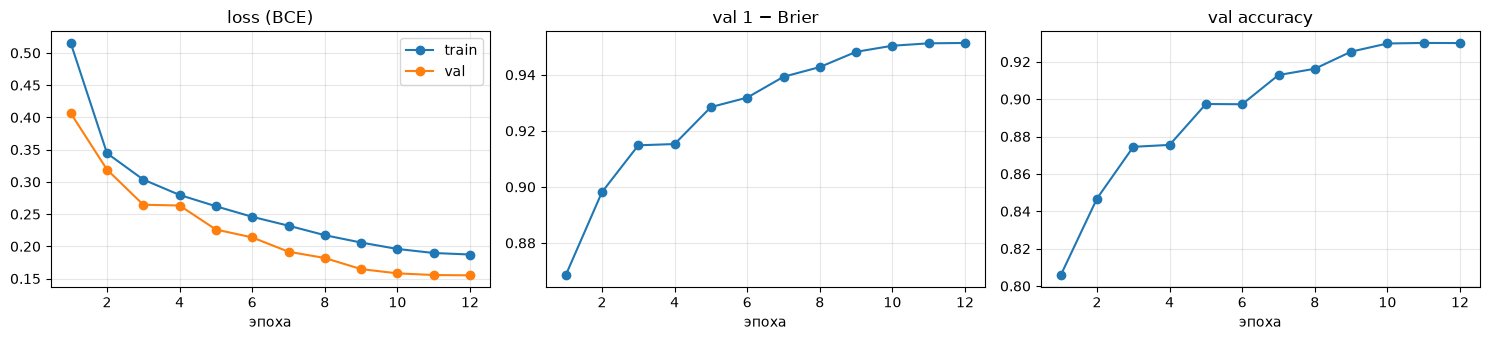

In [18]:
# 5.6 Кривые обучения
if HISTORY_PATH.exists():
    history = pd.read_csv(HISTORY_PATH)
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="val")
    axes[0].set_title("loss (BCE)")
    axes[0].legend()
    axes[1].plot(history["epoch"], history["val_score"], marker="o")
    axes[1].set_title("val 1 − Brier")
    axes[2].plot(history["epoch"], history["val_acc"], marker="o")
    axes[2].set_title("val accuracy")
    for ax in axes:
        ax.set_xlabel("эпоха")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Валидация и калибровка

- 6.1 Логиты лучшей модели на валидации (17 599 кропов test/real) — для кропа и для его повёрнутой копии.
- 6.2 Метрики до калибровки и диаграмма надёжности.
- 6.3 Temperature scaling с честной оценкой кросс-фитом по фотографиям.
- 6.4 TTA с поворотом: берём, только если 1 − Brier растёт на 0.005 и больше (TTA удваивает время инференса).
- 6.5 Разбор ошибок по группам и самые уверенные ошибки.
- 6.6 Проверка на утечку: не выучила ли модель артефакты JPEG вместо букв.

### Temperature scaling

Нейросети, обученные на BCE, часто бывают слишком уверены. Самая простая поправка — поделить логит на одно число $T$:

$$p_{180} = \sigma\left(\frac{z}{T}\right)$$

- $z$ — логит модели, $\sigma$ — сигмоида;
- $T > 1$ делает вероятности осторожнее (ближе к 0.5), $T < 1$ — увереннее;
- $T$ подбираем на валидации, минимизируя logloss. Точность от этого не меняется (порядок предсказаний тот же), меняется только уверенность — ровно то, за что штрафует Brier.

### TTA с поворотом

Если кроп перевёрнут, его повёрнутая на 180° копия стоит правильно. Модель даёт два независимых свидетельства, усредняем их.

In [19]:
%%writefile src/calibration.py
"""Калибровка и анализ валидации: temperature scaling, TTA с поворотом, диаграмма надёжности,
разбор ошибок по группам и проверка на утечку через артефакты JPEG."""
import re

import numpy as np
import pandas as pd
import torch
from PIL import Image

from src.data import CropDataset, resize_pad, to_tensor
from src.train import evaluate
from src.utils import to_rgb


# ---------------------------------------------------------------- temperature scaling

def _nll(z: np.ndarray, y: np.ndarray) -> float:
    return float(np.mean(np.logaddexp(0, z) - y * z))


def fit_temperature(logits: np.ndarray, y: np.ndarray, t_min: float = 0.05, t_max: float = 20.0,
                    iters: int = 100) -> float:
    """T = argmin NLL(σ(z / T), y). NLL выпукла по β = 1 / T, поэтому хватает поиска
    золотым сечением по β на отрезке [1 / t_max, 1 / t_min]."""
    a, b = 1 / t_max, 1 / t_min
    g = (np.sqrt(5) - 1) / 2
    for _ in range(iters):
        c, d = b - g * (b - a), a + g * (b - a)
        if _nll(logits * c, y) < _nll(logits * d, y):
            b = d
        else:
            a = c
    return float(2 / (a + b))


def crossfit_temperature(logits: np.ndarray, y: np.ndarray, groups: np.ndarray, seed: int = 42):
    """Честная оценка калибровки: исходные фото делим на две половины, T подбираем на одной
    и применяем к другой (и наоборот). Возвращает откалиброванные логиты и две температуры."""
    uniq = np.unique(groups)
    half = np.random.default_rng(seed).permutation(uniq)[: len(uniq) // 2]
    mask = np.isin(groups, half)
    z_cal, temps = np.empty(len(logits), dtype=np.float64), []
    for m in (mask, ~mask):
        t = fit_temperature(logits[~m], y[~m])
        z_cal[m] = logits[m] / t
        temps.append(t)
    return z_cal, temps


def reliability(p: np.ndarray, y: np.ndarray, n_bins: int = 10):
    """Корзины по предсказанной вероятности: средняя уверенность против реальной доли y=1.
    ECE — взвешенное среднее расхождение между ними (0 — идеальная калибровка)."""
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    table = (pd.DataFrame({"bin": bins, "p": p, "y": y}).groupby("bin")
             .agg(mean_p=("p", "mean"), frac_pos=("y", "mean"), n=("y", "size")).reset_index())
    ece = float((table["n"] * (table["mean_p"] - table["frac_pos"]).abs()).sum() / len(p))
    return table, ece


# ---------------------------------------------------------------- TTA

@torch.no_grad()
def predict_logits_pair(model, loader, device):
    """Логиты для кропа и для него же, повёрнутого на 180°. Поворачиваем уже готовый тензор:
    при паддинге по центру это то же самое, что повернуть кроп до препроцессинга
    (с точностью до сдвига на 1 px при нечётном паддинге)."""
    model.eval()
    z, z_rot = [], []
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        z.append(model(x).float().squeeze(1).cpu())
        z_rot.append(model(torch.rot90(x, 2, dims=(2, 3))).float().squeeze(1).cpu())
    return torch.cat(z).numpy(), torch.cat(z_rot).numpy()


def tta_logits(z: np.ndarray, z_rot: np.ndarray) -> np.ndarray:
    """Если кроп перевёрнут, его повёрнутая копия стоит правильно — у неё логит «с обратным знаком».
    Усредняем оба свидетельства."""
    return (z - z_rot) / 2


# ---------------------------------------------------------------- разбор ошибок

def text_type(t) -> str:
    t = t if isinstance(t, str) else ""
    cyr, lat = bool(re.search("[А-Яа-яЁё]", t)), bool(re.search("[A-Za-z]", t))
    if cyr and lat:
        return "кириллица + латиница"
    if cyr:
        return "кириллица"
    if lat:
        return "латиница"
    if re.search("[0-9]", t):
        return "только цифры"
    return "без букв и цифр"


def group_report(df: pd.DataFrame, logits: np.ndarray, y: np.ndarray, by: str) -> pd.DataFrame:
    """Метрики по группам: сколько кропов, accuracy, 1 − Brier."""
    rows = []
    for g, idx in df.groupby(by, observed=True).indices.items():
        m = evaluate(logits[idx], y[idx])
        rows.append({by: g, "кропов": len(idx), "доля": round(len(idx) / len(df), 3),
                     "acc": round(m["acc"], 4), "1 - Brier": round(m["score"], 4)})
    return pd.DataFrame(rows).sort_values("кропов", ascending=False).reset_index(drop=True)


# ---------------------------------------------------------------- проверка на утечку

class ShiftedValDataset(CropDataset):
    """Та же валидация, но кроп расширен на 1–7 px симметрично (слева и справа на одно и то же
    число пикселей, сверху и снизу — тоже), берём реальные пиксели из сохранённых полей.
    Сдвигается «фаза» сетки JPEG-блоков 8×8 относительно краёв кропа, а текст не меняется,
    и расширение симметрично, поэтому поворот его не выдаёт. Если модель смотрит на буквы,
    а не на сетку сжатия, метрики почти не изменятся."""

    def __getitem__(self, i):
        img = to_rgb(Image.open(self.root / self.paths[i]))
        W, H = img.size
        x0, y0, x1, y1 = self.boxes[i]
        x0, y0 = int(x0), int(y0)
        x1, y1 = max(x0 + 1, int(np.ceil(x1))), max(y0 + 1, int(np.ceil(y1)))
        rng = np.random.default_rng(1000 + i)
        dx = min(x0, W - x1, int(rng.integers(1, 8)))
        dy = min(y0, H - y1, int(rng.integers(1, 8)))
        img = img.crop((x0 - dx, y0 - dy, x1 + dx, y1 + dy))
        y = int(self.labels[i])
        if y:
            img = img.transpose(Image.Transpose.ROTATE_180)
        return to_tensor(resize_pad(img)), torch.tensor(y, dtype=torch.float32)


def update_checkpoint(path, **fields) -> None:
    """Дописываем в чекпоинт параметры инференса (температура, TTA), не трогая веса."""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    ckpt.update(fields)
    torch.save(ckpt, path)

Overwriting src/calibration.py


In [20]:
# 6.1 Логиты лучшей модели на валидации: для кропа и для его повёрнутой копии
from src.train import sigmoid
from src.calibration import (fit_temperature, crossfit_temperature, reliability, predict_logits_pair,
                             tta_logits, text_type, group_report, ShiftedValDataset, update_checkpoint)

if HAS_CROPS:
    val_loader = make_loader(val_ds, shuffle=False, batch_size=512, num_workers=0)
    y_val = val_ds.labels.astype(np.float64)
    z_val, z_val_rot = predict_logits_pair(model, val_loader, DEVICE)
    groups = val_df["image"].astype(str).to_numpy()  # исходное фото — для кросс-фита
    print("логитов:", len(z_val), "| доля y=1:", y_val.mean().round(3))

логитов: 17599 | доля y=1: 0.497


T на двух половинах фото: [0.98, 1.079]
                                  score   brier  logloss   acc
без калибровки                   0.9514  0.0486   0.1551  0.93
temperature scaling (кросс-фит)  0.9513  0.0487   0.1555  0.93


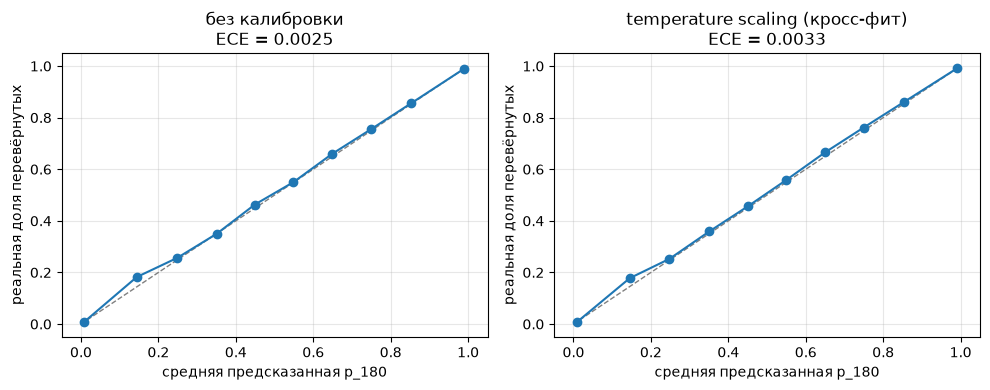

In [21]:
# 6.2–6.3 Метрики до и после temperature scaling (кросс-фит по фото) + диаграммы надёжности
def reliability_plot(ax, p, y, title):
    table, ece = reliability(p, y)
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)  # идеальная калибровка
    ax.plot(table["mean_p"], table["frac_pos"], marker="o")
    ax.set_title(f"{title}\nECE = {ece:.4f}")
    ax.set_xlabel("средняя предсказанная p_180")
    ax.set_ylabel("реальная доля перевёрнутых")
    ax.grid(alpha=0.3)


if HAS_CROPS:
    z_cf, temps_cf = crossfit_temperature(z_val, y_val, groups, seed=SEED)
    print("T на двух половинах фото:", [round(t, 3) for t in temps_cf])
    print(pd.DataFrame({"без калибровки": evaluate(z_val, y_val),
                        "temperature scaling (кросс-фит)": evaluate(z_cf, y_val)}).T.round(4))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    reliability_plot(axes[0], sigmoid(z_val), y_val, "без калибровки")
    reliability_plot(axes[1], sigmoid(z_cf), y_val, "temperature scaling (кросс-фит)")
    plt.tight_layout()
    plt.show()

In [22]:
# 6.4 TTA с поворотом
TTA_MIN_GAIN = 0.005  # TTA удваивает время инференса: берём, только если прирост заметный

if HAS_CROPS:
    z_tta = tta_logits(z_val, z_val_rot)
    z_tta_cf, _ = crossfit_temperature(z_tta, y_val, groups, seed=SEED)
    single, tta = evaluate(z_cf, y_val), evaluate(z_tta_cf, y_val)
    print(pd.DataFrame({"один проход": single, "TTA (x и rot180(x))": tta}).T.round(4))

    USE_TTA = bool(tta["score"] - single["score"] >= TTA_MIN_GAIN)
    z_final = z_tta if USE_TTA else z_val
    TEMPERATURE = fit_temperature(z_final, y_val)  # итоговая T — на всей валидации
    z_cal_final = z_final / TEMPERATURE
    print(f"прирост от TTA: {tta['score'] - single['score']:+.4f} -> USE_TTA = {USE_TTA}; "
          f"итоговая T = {TEMPERATURE:.3f}")
    if TRAIN:
        # T и флаг TTA дописываем в чекпоинт, только если модель обучили в этом запуске
        update_checkpoint(CKPT_PATH, temperature=TEMPERATURE, tta=USE_TTA)
        print("T и TTA сохранены в чекпоинт")
    else:
        # готовые веса не трогаем: инференс берёт T и TTA из чекпоинта репозитория
        print(f"TRAIN = False, чекпоинт не меняем: в нём T = {ckpt.get('temperature', 1.0):.3f}, "
              f"TTA = {ckpt.get('tta', False)}")

                      score   brier  logloss     acc
один проход          0.9513  0.0487   0.1555  0.9300
TTA (x и rot180(x))  0.9586  0.0414   0.1336  0.9416
прирост от TTA: +0.0073 -> USE_TTA = True; итоговая T = 0.866
TRAIN = False, чекпоинт не меняем: в нём T = 0.866, TTA = True


             тип текста  кропов   доля     acc  1 - Brier
0             кириллица   12738  0.724  0.9549     0.9678
1              латиница    2829  0.161  0.9138     0.9383
2          только цифры    1615  0.092  0.8947     0.9282
3  кириллица + латиница     397  0.023  0.9244     0.9465
4       без букв и цифр      20  0.001  0.5500     0.6953 

  длина текста  кропов   доля     acc  1 - Brier
0           9+    8702  0.494  0.9607     0.9719
1          4–8    6611  0.376  0.9380     0.9565
2  1–3 символа    2286  0.130  0.8797     0.9145 

                     из абзаца  кропов   доля     acc  1 - Brier
0  полоса многострочного бокса   11396  0.648  0.9477     0.9624
1            однострочный бокс    6203  0.352  0.9305     0.9518 



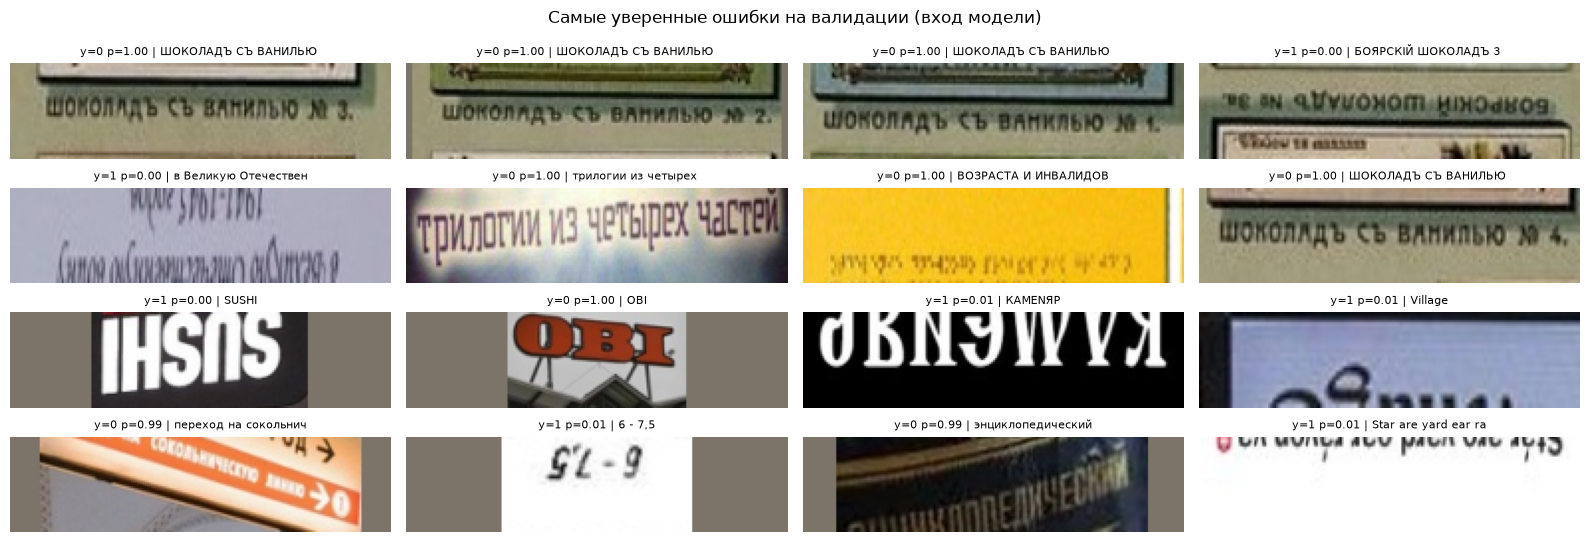

In [23]:
# 6.5 Разбор ошибок: по типу текста, длине, «полоса из абзаца или отдельный бокс» + самые уверенные ошибки
if HAS_CROPS:
    ana = val_df[["path", "text"]].copy()
    ana["тип текста"] = ana["text"].map(text_type)
    n_chars = ana["text"].fillna("").str.len()
    ana["длина текста"] = pd.cut(n_chars, [-1, 3, 8, 1000], labels=["1–3 символа", "4–8", "9+"])
    box_key = ana["path"].str.rsplit("_", n=1).str[0]  # путь без номера строки -> исходный бокс
    ana["из абзаца"] = np.where(box_key.map(box_key.value_counts()) > 1,
                                "полоса многострочного бокса", "однострочный бокс")
    for col in ["тип текста", "длина текста", "из абзаца"]:
        print(group_report(ana, z_cal_final, y_val, col), "\n")

    p_val = sigmoid(z_cal_final)
    worst = np.argsort(-np.abs(p_val - y_val))[:16]
    fig, axes = plt.subplots(4, 4, figsize=(16, 5.6))
    for ax, i in zip(axes.ravel(), worst):
        x, y = val_ds[i]
        ax.imshow(denormalize(x))
        ax.axis("off")
        ax.set_title(f"y={int(y)} p={p_val[i]:.2f} | {str(ana['text'][i])[:20]}", fontsize=8)
    fig.suptitle("Самые уверенные ошибки на валидации (вход модели)")
    plt.tight_layout()
    plt.show()

In [24]:
# 6.6 Проверка на утечку: сдвигаем «фазу» сетки JPEG относительно краёв кропа, текст не трогаем
if HAS_CROPS:
    shifted_loader = make_loader(ShiftedValDataset(val_df, CROPS_DIR, train=False, seed=SEED),
                                 shuffle=False, batch_size=512, num_workers=0)
    z_sh, z_sh_rot = predict_logits_pair(model, shifted_loader, DEVICE)
    z_sh_final = tta_logits(z_sh, z_sh_rot) if USE_TTA else z_sh
    print(pd.DataFrame({"валидация": evaluate(z_cal_final, y_val),
                        "сдвиг сетки JPEG": evaluate(z_sh_final / TEMPERATURE, y_val)}).T.round(4))

                   score   brier  logloss     acc
валидация         0.9586  0.0414   0.1333  0.9416
сдвиг сетки JPEG  0.9612  0.0388   0.1258  0.9454


## 7. Скорость и компактность

- 7.1 Размер: параметры, FLOPs, файл весов.
- 7.2 Задержка модели на CPU: батч 1 (один бокс — худший случай для онлайн-обработки) и батч 64 (пакетная обработка), в один поток и во все потоки.
- 7.3 Полный цикл на CPU в одном процессе: чтение png, препроцессинг и модель — сколько кропов в секунду обрабатывает весь конвейер.

Если в разделе 6 включён TTA, время модели удваивается: кроп прогоняется дважды. Замеры зависят от процессора, поэтому рядом с цифрами указываем, на чём мерили.

In [25]:
# 7.1–7.3 Размер модели, задержка на CPU и полный цикл обработки (без TTA и с TTA)
import time

from src.model import count_params, count_flops


def measure_latency(model, batch_size, n_threads, n_iter=50, warmup=10):
    # медианное время прохода модели на CPU по случайному батчу нужного размера
    torch.set_num_threads(n_threads)
    x = torch.randn(batch_size, 3, IMG_H, IMG_W)
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        times = []
        for _ in range(n_iter):
            t0 = time.perf_counter()
            model(x)
            times.append(time.perf_counter() - t0)
    ms = float(np.median(times)) * 1000
    return {"батч": batch_size, "потоков": n_threads, "мс на батч": round(ms, 2),
            "мс на кроп": round(ms / batch_size, 3), "кропов/с": round(batch_size / ms * 1000)}


def end_to_end(model, loader, n, tta):
    # полный цикл: чтение png + препроцессинг + модель (с TTA — два прохода: кроп и его поворот)
    t0 = time.perf_counter()
    with torch.inference_mode():
        for x, _ in loader:
            model(x)
            if tta:
                model(torch.rot90(x, 2, dims=(2, 3)))
    return n / (time.perf_counter() - t0)


if CKPT_PATH.exists():
    cpu_model, _ = load_checkpoint(CKPT_PATH, torch.device("cpu"))
    default_threads = torch.get_num_threads()
    print(f"параметров: {count_params(cpu_model):,} | FLOPs на кроп: {count_flops(cpu_model) / 1e6:.1f} M | "
          f"файл весов: {CKPT_PATH.stat().st_size / 2**20:.1f} МБ")
    rows = [measure_latency(cpu_model, bs, th) for bs in (1, 64) for th in (1, default_threads)]
    print(pd.DataFrame(rows).to_string(index=False))

    torch.set_num_threads(default_threads)
    n = min(2000, len(test_paths))
    e2e_loader = make_loader(TestDataset(test_paths[:n]), shuffle=False, batch_size=64, num_workers=0)
    print(f"полный цикл на CPU, 1 процесс: без TTA {end_to_end(cpu_model, e2e_loader, n, tta=False):.0f} кропов/с | "
          f"с TTA {end_to_end(cpu_model, e2e_loader, n, tta=True):.0f} кропов/с")

параметров: 2,972,913 | FLOPs на кроп: 86.7 M | файл весов: 11.5 МБ
 батч  потоков  мс на батч  мс на кроп  кропов/с
    1        1        6.40       6.396       156
    1        6        7.07       7.068       141
   64        1      163.11       2.549       392
   64        6       70.10       1.095       913
полный цикл на CPU, 1 процесс: без TTA 399 кропов/с | с TTA 285 кропов/с


## 8. Инференс и submission

- 8.1 Загружаем лучший чекпоинт: веса, температуру $T$ и флаг TTA (подобраны в разделе 6).
- 8.2 Логиты для 20 000 тестовых кропов, $p_{180} = \sigma(z / T)$. Инференс нарочно на CPU в fp32: на GPU (TF32 по умолчанию на RTX 30xx/40xx) вероятности отличаются от CPU до ~0.006 и зависят от видеокарты.
- 8.3 `submission.csv`: `image_id` без расширения, порядок как в `sample_submission.csv`, `p_180` с 5 знаками после запятой. В другом окружении у отдельных строк возможна разница в 5-м знаке: на одном и том же процессоре torch 2.14 CPU- и CUDA-сборки дали 2 отличающиеся строки из 20 000, максимум 4e-5. На Brier это не влияет (меньше 1e-8).
- 8.4 Проверки формата, среднее `p_180` и распределение предсказаний: по ним видно, какая доля теста перевёрнута.
- 8.5 md5 файла: повторный запуск на той же машине даёт тот же хеш.

In [26]:
# 8.1–8.2 Лучший чекпоинт (веса, T, TTA) -> вероятности для тестовых кропов
from src.train import predict_logits, sigmoid
from src.calibration import predict_logits_pair, tta_logits

# инференс всегда на CPU в fp32: так submission не зависит от видеокарты
# (на GPU RTX 30xx/40xx свёртки по умолчанию идут в TF32, и вероятности отличаются до ~0.006)
INFER_DEVICE = torch.device("cpu")
model_inf, ckpt_inf = load_checkpoint(CKPT_PATH, INFER_DEVICE)
TEMPERATURE_INF = ckpt_inf.get("temperature", 1.0)
USE_TTA_INF = ckpt_inf.get("tta", False)
print(f"чекпоинт: эпоха {ckpt_inf['epoch']} | T = {TEMPERATURE_INF:.3f} | TTA = {USE_TTA_INF}")

test_loader = make_loader(TestDataset(test_paths), shuffle=False, batch_size=512, num_workers=NUM_WORKERS)
if USE_TTA_INF:
    z_test = tta_logits(*predict_logits_pair(model_inf, test_loader, INFER_DEVICE))
else:
    z_test = predict_logits(model_inf, test_loader, INFER_DEVICE)
p_test = sigmoid(z_test / TEMPERATURE_INF)

чекпоинт: эпоха 12 | T = 0.866 | TTA = True


строк: 20000 | среднее p_180: 0.499 | доля p_180 > 0.5: 0.500
md5 submission.csv: 932cc02d8bf3e3036236aad67d4727c6


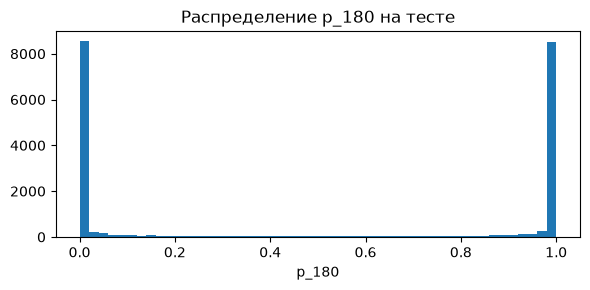

In [27]:
# 8.3–8.5 submission.csv, проверки формата, распределение p_180 и хеш файла
import hashlib

SUBMISSION_PATH = Path("submission.csv")
pred = pd.DataFrame({"image_id": [p.stem for p in test_paths], "p_180": np.round(p_test, 5)})
submission = sample_sub[["image_id"]].merge(pred, on="image_id", how="left")  # порядок как в sample_submission
submission.to_csv(SUBMISSION_PATH, index=False, float_format="%.5f")

assert list(submission.columns) == ["image_id", "p_180"]
assert len(submission) == len(sample_sub) and set(submission["image_id"]) == set(sample_sub["image_id"])
assert submission["p_180"].notna().all() and submission["p_180"].between(0, 1).all()
print(f"строк: {len(submission)} | среднее p_180: {submission['p_180'].mean():.3f} | "
      f"доля p_180 > 0.5: {(submission['p_180'] > 0.5).mean():.3f}")
print("md5 submission.csv:", hashlib.md5(SUBMISSION_PATH.read_bytes()).hexdigest())

plt.figure(figsize=(6, 3))
plt.hist(submission["p_180"], bins=50)
plt.title("Распределение p_180 на тесте")
plt.xlabel("p_180")
plt.tight_layout()
plt.show()

## 9. Итоги

Решение: MobileNetV3-Large на входе 48 × 192, обученная на кропах RusTitW с метками, которые мы создаём сами поворотом; TTA с поворотом и temperature scaling. Валидация на отдельных фотографиях RusTitW оказалась честной и слегка пессимистичной: тест выше валидации.

### 9.1 Качество

| | 1 − Brier | accuracy |
|---|---|---|
| валидация, один проход | 0.9513 | 0.930 |
| валидация, TTA + temperature scaling | 0.9586 | 0.942 |
| тест (лидерборд) | 0.9675 | — |

- Тест выше валидации примерно на 0.009. Вероятная причина — тестовые кропы длиннее (медиана w/h 4.9 против 2.5), а длинный текст модель определяет лучше всего: 0.972 на кропах с 9+ символами против 0.915 на 1–3 символах.
- Слабее всего — латиница (0.938) и строки из одних цифр (0.928): часть из них неоднозначна при повороте в принципе («69», «808»), и там правильный ответ — вероятность около 0.5.
- Тест сбалансирован: среднее `p_180` = 0.499, поправка на долю перевёрнутых не нужна.

### 9.2 Скорость и компактность (CPU Ryzen 5 5600)

- 2.97 млн параметров, 86.7 MFLOPs на кроп, файл весов 11.5 МБ.
- Батч 64, 6 потоков: около 1 мс на кроп, 900–1000 кропов/с; один бокс (батч 1) — ~7.5 мс.
- Полный цикл в одном процессе (чтение png, препроцессинг, модель): около 400 кропов/с без TTA и 270–280 с TTA.
- TTA даёт +0.007 на валидации за ×1.4–1.5 времени конвейера. Если в проде важнее скорость, его можно выключить флагом `tta` в чекпоинте.

### 9.3 Что пробовал

| прогон | модель | обучение | где | val 1 − Brier |
|---|---|---|---|---|
| 1 | MobileNetV3-Small | случайный поворот | Mac (MPS), 4 эпохи | 0.849 (с TTA 0.861) |
| 2 | MobileNetV3-Small | пары | RTX 4060, 6 эпох | 0.879 |
| 3 | MobileNetV3-Large | пары | RTX 4060, 12 эпох | 0.951 (с TTA 0.959) |

- Прогоны 1–2 остановили досрочно: качество росло медленно, а train loss совпадал с val loss — модель недообучалась. Другие причины проверили и исключили: MPS считает так же, как CPU (разница логитов ~1e-5); полосы из разрезанных абзацев не хуже цельных боксов; утечки через артефакты JPEG нет (раздел 6.6). Вывод — не хватало ёмкости, поэтому Large.
- Пары (RotNet) при равном числе увиденных картинок дали то же качество, что и случайный поворот; оставили их.
- Temperature scaling для одного прохода почти ничего не меняет (T ≈ 1): модель, обученная на BCE, уже хорошо откалибрована. С TTA T = 0.866 слегка «заостряет» усреднённые логиты.

### 9.4 Что можно улучшить

- Скорость: дистилляция Large → Small, экспорт в ONNX Runtime и квантование int8, отказ от TTA.
- Качество: данные ближе к Авито — скриншоты, карточки товаров, цены и телефоны (цифры сейчас самая слабая группа); больше синтетики RusTitW; вход высотой 64; автоматическая псевдоразметка тестового домена уверенными предсказаниями модели.

